# 🪐 Prosperity Round 1 — EDA Notebook
**Products:** `ASH_COATED_OSMIUM` · `INTARIAN_PEPPER_ROOT`  
**Data:** Days −2, −1, 0 · Price snapshots + Market trades

---

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Mid Price — All Days](#3-mid-price--all-days)
4. [INTARIAN PEPPER ROOT — Trend Analysis](#4-intarian-pepper-root--trend-analysis)
5. [ASH COATED OSMIUM — Mean Reversion Analysis](#5-ash-coated-osmium--mean-reversion-analysis)
6. [Spread & Order Book Depth](#6-spread--order-book-depth)
7. [Trade Flow Analysis](#7-trade-flow-analysis)
8. [Autocorrelation & Return Analysis](#8-autocorrelation--return-analysis)
9. [Strategy Signals](#9-strategy-signals)
10. [Key Takeaways](#10-key-takeaways)


## 1. Setup & Data Loading

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13

COLORS = {
    'ASH_COATED_OSMIUM':      '#4C9BE8',
    'INTARIAN_PEPPER_ROOT':   '#E8804C',
    'bid': '#2ecc71',
    'ask': '#e74c3c',
}

# ── File paths ──────────────────────────────────────────────────────────────
price_files = {
    -2: "./data/round_1/prices_round_1_day_-2.csv",
    -1: "./data/round_1/prices_round_1_day_-1.csv",
     0: "./data/round_1/prices_round_1_day_0.csv",
}
trade_files = {
    -2: "./data/round_1/trades_round_1_day_-2.csv",
    -1: "./data/round_1/trades_round_1_day_-1.csv",
     0: "./data/round_1/trades_round_1_day_0.csv",
}

OFFSET = 1_000_000   # stitch days end-to-end

# ── Load & stitch ────────────────────────────────────────────────────────────
price_dfs, trade_dfs = [], []

for i, (day, path) in enumerate(price_files.items()):
    df = pd.read_csv(path, sep=';')
    df['global_ts'] = df['timestamp'] + i * OFFSET
    df['day'] = day
    price_dfs.append(df)

for i, (day, path) in enumerate(trade_files.items()):
    df = pd.read_csv(path, sep=';')
    df['global_ts'] = df['timestamp'] + i * OFFSET
    df['day'] = day
    trade_dfs.append(df)

prices = pd.concat(price_dfs, ignore_index=True).sort_values('global_ts')
trades = pd.concat(trade_dfs, ignore_index=True).sort_values('global_ts')

# Remove zero mid-prices (missing book entries)
prices = prices[prices['mid_price'] > 0].copy()

print(f"Prices shape: {prices.shape}")
print(f"Trades shape: {trades.shape}")


Prices shape: (59897, 18)
Trades shape: (2276, 9)


## 2. Dataset Overview

In [25]:
print("=== PRICES ===")
display(prices.head(4))
display(prices.dtypes)
print(f"\nProducts: {prices['product'].unique()}")
print(f"Days:     {sorted(prices['day'].unique())}")
print(f"Timestamps per day per product:")
print(prices.groupby(['day','product']).size().unstack())


=== PRICES ===


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_ts
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,100
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,100


day                  int64
timestamp            int64
product             object
bid_price_1        float64
bid_volume_1       float64
bid_price_2        float64
bid_volume_2       float64
bid_price_3        float64
bid_volume_3       float64
ask_price_1        float64
ask_volume_1       float64
ask_price_2        float64
ask_volume_2       float64
ask_price_3        float64
ask_volume_3       float64
mid_price          float64
profit_and_loss    float64
global_ts            int64
dtype: object


Products: ['INTARIAN_PEPPER_ROOT' 'ASH_COATED_OSMIUM']
Days:     [np.int64(-2), np.int64(-1), np.int64(0)]
Timestamps per day per product:
product  ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT
day                                             
-2                    9982                  9984
-1                    9983                  9983
 0                    9986                  9979


In [26]:
print("=== TRADES ===")
display(trades.head(4))
print(f"\nProducts: {trades['symbol'].unique()}")
print(f"\nTrades per day per product:")
print(trades.groupby(['day','symbol']).size().unstack(fill_value=0))
print(f"\nQuantity stats:")
display(trades.groupby('symbol')['quantity'].describe().round(2))


=== TRADES ===


,timestamp,buyer,seller,symbol,currency,price,quantity,global_ts,day
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6,700,-2
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2,900,-2
2,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7,1000,-2
3,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8,2500,-2



Products: ['ASH_COATED_OSMIUM' 'INTARIAN_PEPPER_ROOT']

Trades per day per product:
symbol  ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT
day                                            
-2                    429                   344
-1                    425                   335
 0                    411                   332

Quantity stats:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
ASH_COATED_OSMIUM,1265.0,5.21,2.28,2.0,3.0,5.0,6.0,10.0
INTARIAN_PEPPER_ROOT,1011.0,5.17,1.51,2.0,4.0,5.0,6.0,8.0


In [27]:
print("=== SUMMARY STATISTICS (per product, all days) ===")
for prod in ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']:
    sub = prices[prices['product'] == prod]
    sub = sub.copy()
    sub['spread'] = sub['ask_price_1'] - sub['bid_price_1']
    print(f"\n{'─'*55}")
    print(f"  {prod}")
    print(f"{'─'*55}")
    print(sub[['mid_price','spread']].describe().round(2))


=== SUMMARY STATISTICS (per product, all days) ===

───────────────────────────────────────────────────────
  ASH_COATED_OSMIUM
───────────────────────────────────────────────────────
       mid_price    spread
count   29951.00  27644.00
mean    10000.20     16.18
std         5.35      2.57
min      9977.00      5.00
25%      9997.00     16.00
50%     10000.50     16.00
75%     10003.50     18.00
max     10023.00     22.00

───────────────────────────────────────────────────────
  INTARIAN_PEPPER_ROOT
───────────────────────────────────────────────────────
       mid_price    spread
count   29946.00  27688.00
mean    11499.89     13.05
std       866.11      2.63
min      9998.50      2.00
25%     10750.00     12.00
50%     11500.00     13.00
75%     12249.50     14.00
max     13007.00     21.00


## 3. Mid Price — All Days

Plot both products side-by-side across all three days with day boundaries marked.

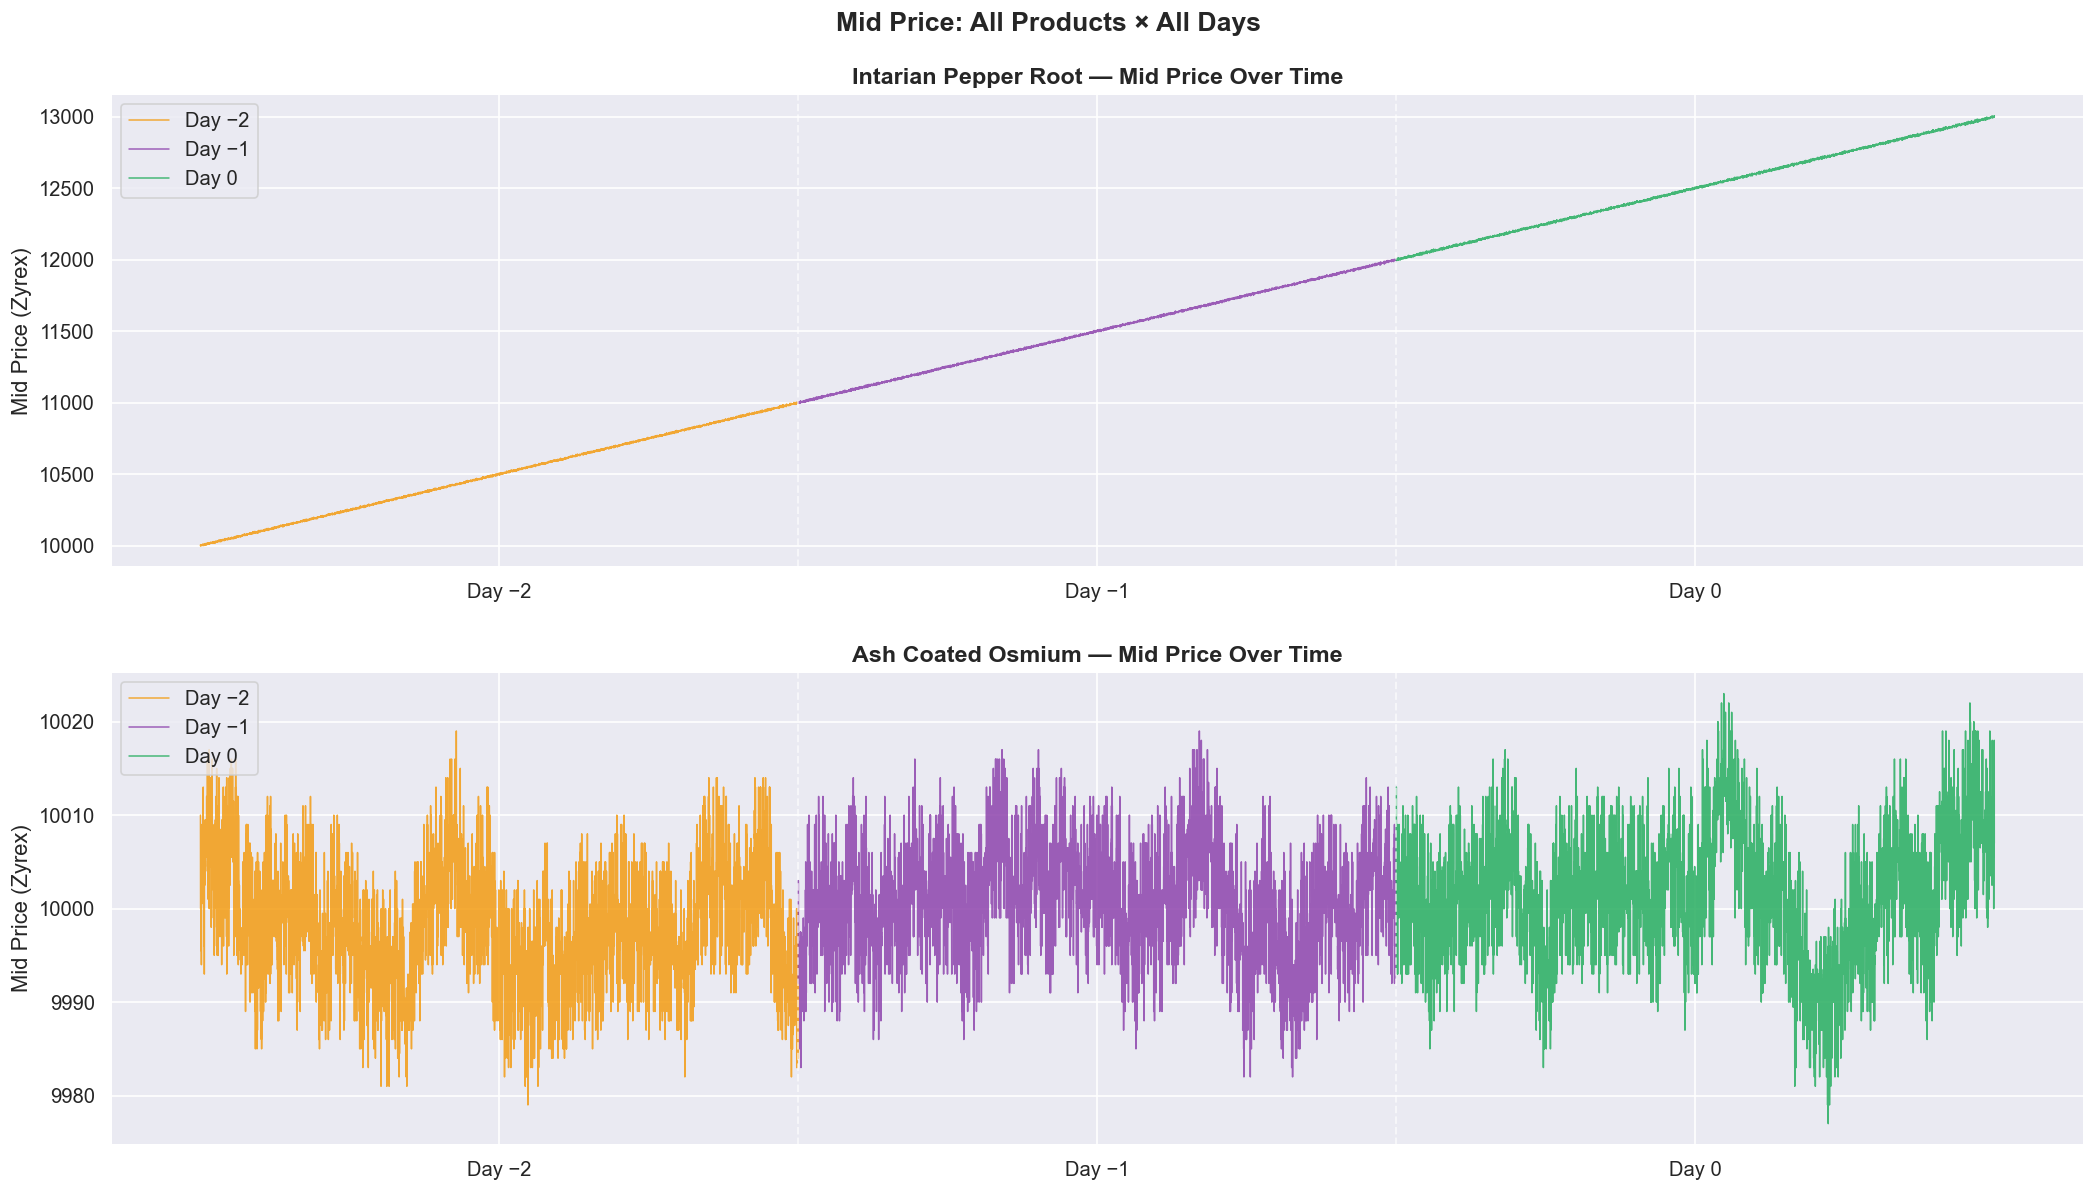

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=False)

day_labels = {-2: 'Day −2', -1: 'Day −1', 0: 'Day 0'}
day_colors = {-2: '#f39c12', -1: '#8e44ad', 0: '#27ae60'}

for ax, prod in zip(axes, ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']):
    sub = prices[prices['product'] == prod]
    
    for day in [-2, -1, 0]:
        dsub = sub[sub['day'] == day]
        ax.plot(dsub['global_ts'], dsub['mid_price'],
                label=day_labels[day], color=day_colors[day], linewidth=0.9, alpha=0.85)
    
    # Day boundary lines
    for i in [1, 2]:
        ax.axvline(i * OFFSET, color='white', linestyle='--', linewidth=1.2, alpha=0.6)
    
    # Day labels on x-axis
    ax.set_xticks([0.5*OFFSET, 1.5*OFFSET, 2.5*OFFSET])
    ax.set_xticklabels(['Day −2', 'Day −1', 'Day 0'])
    ax.set_title(f'{prod.replace("_", " ").title()} — Mid Price Over Time', fontsize=14, fontweight='bold')
    ax.set_ylabel('Mid Price (Zyrex)')
    ax.legend(loc='upper left')

plt.tight_layout(pad=2)
plt.suptitle('Mid Price: All Products × All Days', fontsize=16, fontweight='bold', y=1.01)
plt.show()


## 4. INTARIAN PEPPER ROOT — Trend Analysis

IPR drifts steadily **+1,000 Zyrex per day** and linearly within each day from the day's open to close.  
Key question: **can we estimate the true fair value at each timestamp?**


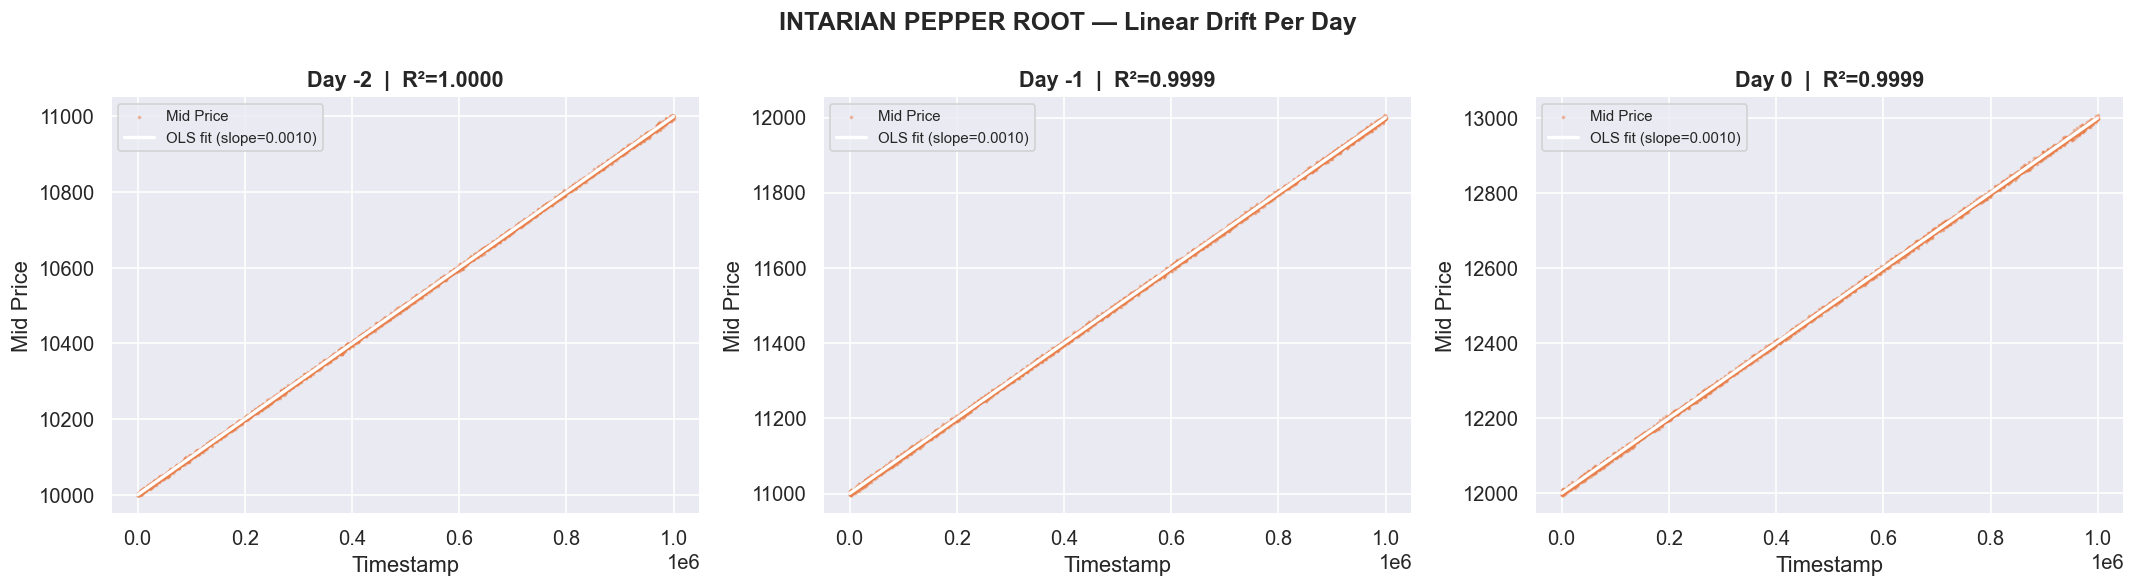

In [29]:
ipr = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT'].copy()

# ── Per-day linear regression to extract drift ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, day in zip(axes, [-2, -1, 0]):
    dsub = ipr[ipr['day'] == day].copy()
    ts = dsub['timestamp'].values
    mp = dsub['mid_price'].values
    
    slope, intercept, r, p, se = stats.linregress(ts, mp)
    fitted = slope * ts + intercept
    
    ax.scatter(ts, mp, s=1.5, alpha=0.4, color=COLORS['INTARIAN_PEPPER_ROOT'], label='Mid Price')
    ax.plot(ts, fitted, color='white', linewidth=2, label=f'OLS fit (slope={slope:.4f})')
    ax.set_title(f'Day {day}  |  R²={r**2:.4f}', fontweight='bold')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Mid Price')
    ax.legend(fontsize=9)

plt.suptitle('INTARIAN PEPPER ROOT — Linear Drift Per Day', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [30]:
# ── Compute fair value (linear fit) and residuals ──────────────────────────
from scipy.stats import linregress

slope_per_day = {}
for day in [-2, -1, 0]:
    dsub = ipr[ipr['day'] == day].copy()
    ts = dsub['timestamp'].values
    mp = dsub['mid_price'].values
    slope, intercept, *_ = linregress(ts, mp)
    slope_per_day[day] = (slope, intercept)
    ipr.loc[ipr['day'] == day, 'fair_value'] = slope * ts + intercept

ipr['residual'] = ipr['mid_price'] - ipr['fair_value']

print("Slope per day (Zyrex/timestamp):")
for day, (s, b) in slope_per_day.items():
    print(f"  Day {day:+d}: slope={s:.5f}  intercept={b:.1f}  (~{s*1e6:.0f} Zyrex/day)")


Slope per day (Zyrex/timestamp):
  Day -2: slope=0.00100  intercept=10000.0  (~1000 Zyrex/day)
  Day -1: slope=0.00100  intercept=11000.0  (~1000 Zyrex/day)
  Day +0: slope=0.00100  intercept=12000.0  (~1000 Zyrex/day)


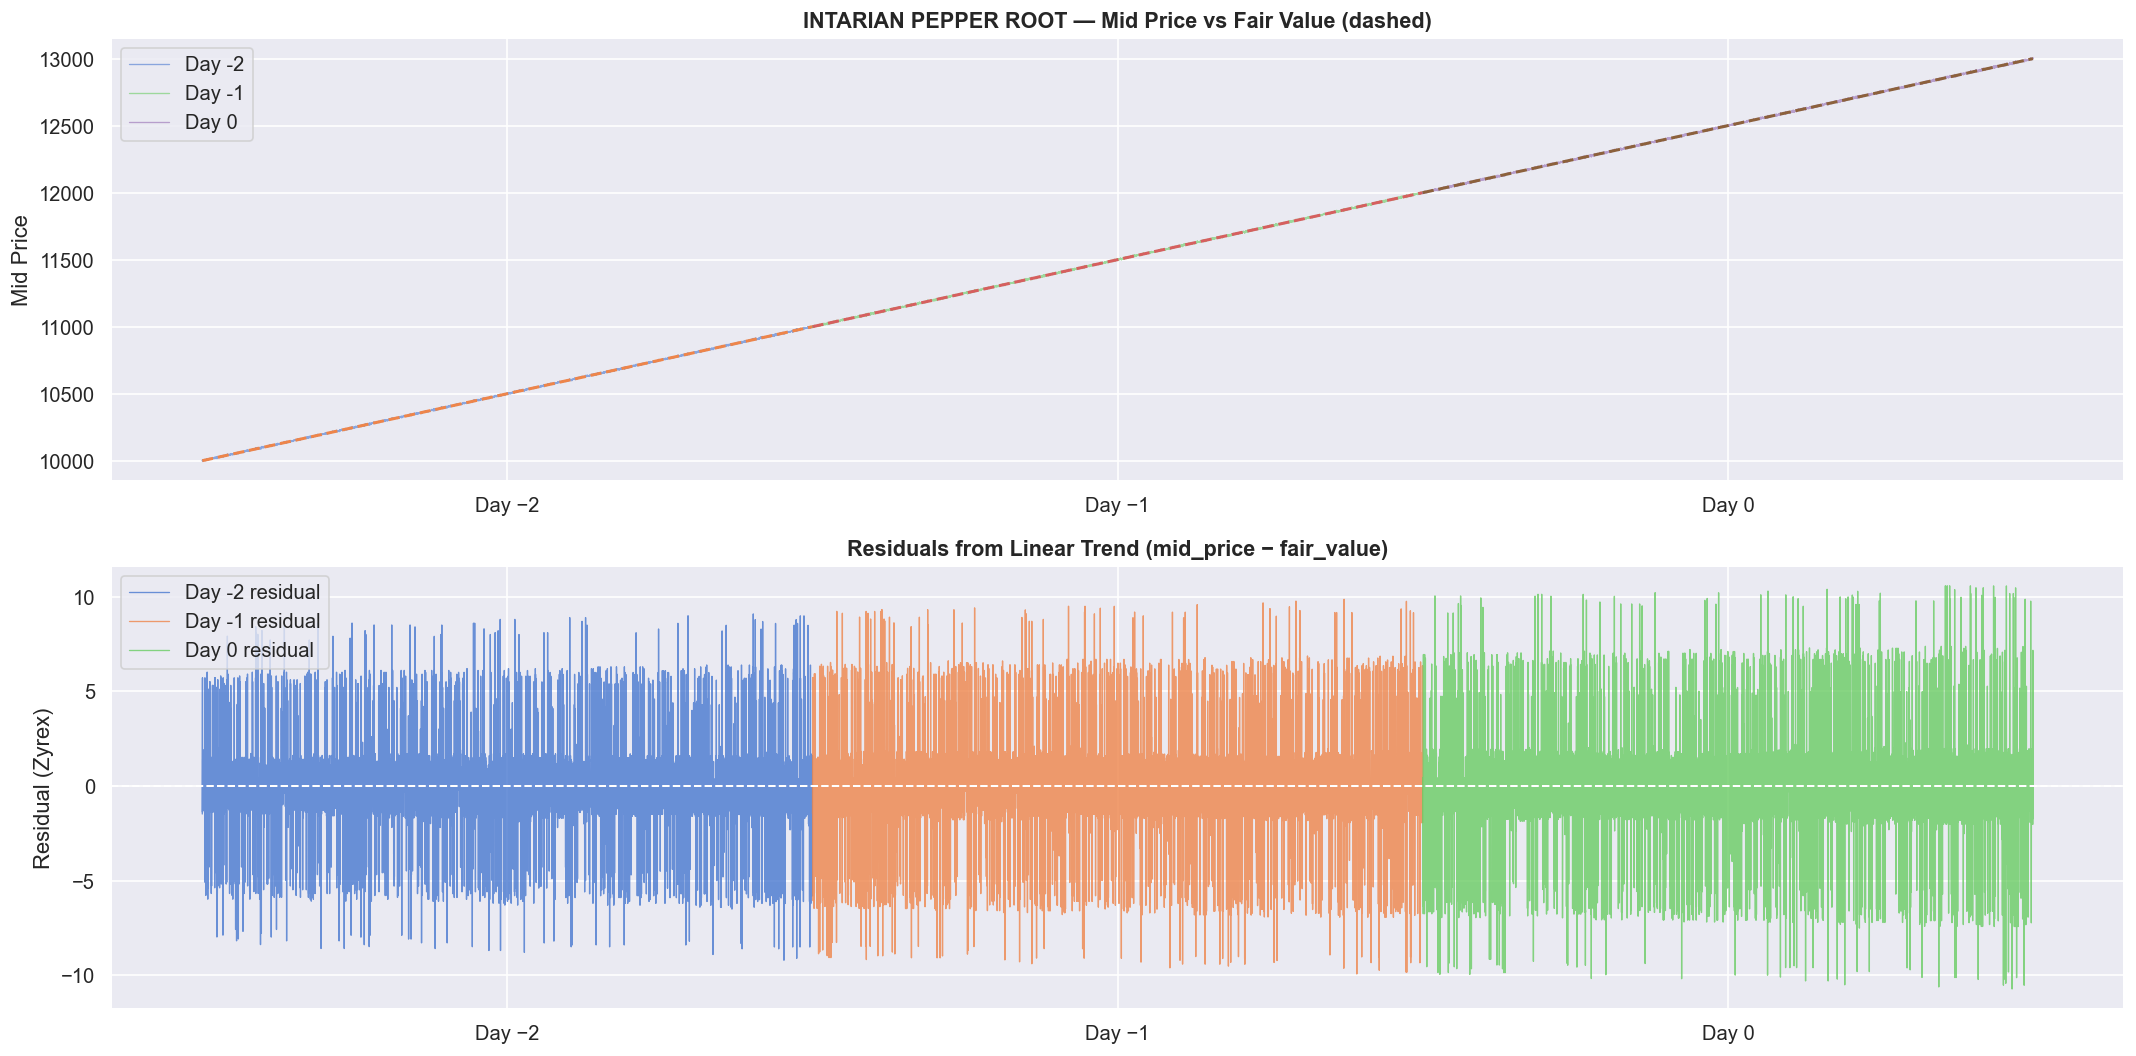

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=False)

# Full plot
ax1, ax2 = axes
for day in [-2, -1, 0]:
    dsub = ipr[ipr["day"] == day]
    ax1.plot(dsub["global_ts"], dsub["mid_price"], linewidth=0.8, alpha=0.6, label=f"Day {day}")
    ax1.plot(dsub["global_ts"], dsub["fair_value"], linewidth=1.8, linestyle="--")

ax1.set_title("INTARIAN PEPPER ROOT — Mid Price vs Fair Value (dashed)", fontweight="bold")
ax1.set_ylabel("Mid Price")
ax1.set_xticks([0.5*OFFSET, 1.5*OFFSET, 2.5*OFFSET])
ax1.set_xticklabels(["Day −2", "Day −1", "Day 0"])
ax1.legend()

# Residuals
for day in [-2, -1, 0]:
    dsub = ipr[ipr["day"] == day]
    ax2.plot(dsub["global_ts"], dsub["residual"], linewidth=0.8, alpha=0.8, label=f"Day {day} residual")

ax2.axhline(0, color="white", linestyle="--", linewidth=1.2)
ax2.set_title("Residuals from Linear Trend (mid_price − fair_value)", fontweight="bold")
ax2.set_ylabel("Residual (Zyrex)")
ax2.set_xticks([0.5*OFFSET, 1.5*OFFSET, 2.5*OFFSET])
ax2.set_xticklabels(["Day −2", "Day −1", "Day 0"])
ax2.legend()

plt.tight_layout()
plt.show()


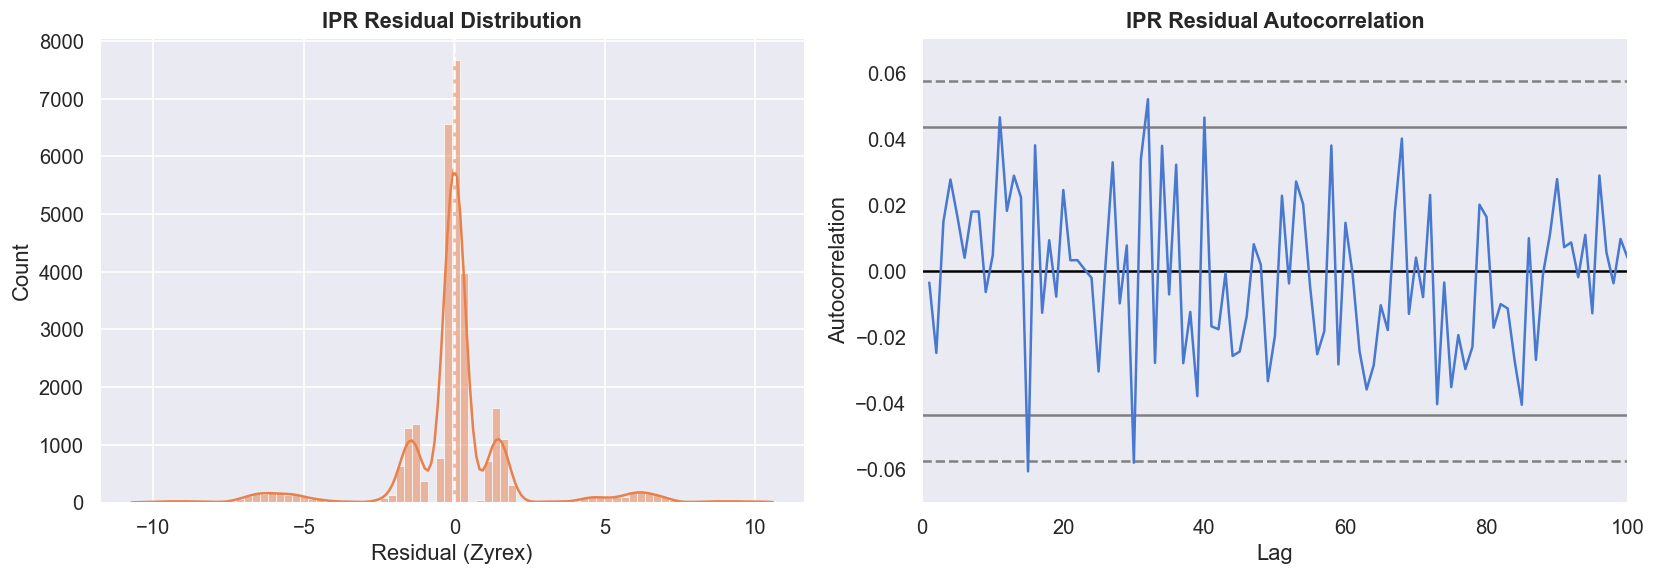

Residual stats: mean=-0.000, std=2.201
Residual is mean-reverting? ADF p-value (approx via autocorr decay): inspect plot above


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
sns.histplot(ipr['residual'].dropna(), bins=80, kde=True, ax=axes[0],
             color=COLORS['INTARIAN_PEPPER_ROOT'])
axes[0].axvline(0, color='white', linestyle='--')
axes[0].set_title('IPR Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Residual (Zyrex)')

# Residual autocorrelation
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(ipr['residual'].dropna().values[:2000], ax=axes[1])
axes[1].set_title('IPR Residual Autocorrelation', fontweight='bold')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

print(f"Residual stats: mean={ipr['residual'].mean():.3f}, std={ipr['residual'].std():.3f}")
print(f"Residual is mean-reverting? ADF p-value (approx via autocorr decay): inspect plot above")


## 5. ASH COATED OSMIUM — Mean Reversion Analysis

ASH is the volatile product. Its mid-price oscillates around a stable mean (~10,000).  
This is a classic **mean-reversion** setup — trade against extreme deviations.


In [33]:
ash = prices[prices['product'] == 'ASH_COATED_OSMIUM'].copy()

# Rolling stats
WINDOW = 200

ash['rolling_mean'] = ash['mid_price'].rolling(WINDOW, min_periods=10).mean()
ash['rolling_std']  = ash['mid_price'].rolling(WINDOW, min_periods=10).std()
ash['z_score']      = (ash['mid_price'] - ash['rolling_mean']) / ash['rolling_std']

print("Rolling window:", WINDOW)
print(f"Z-score stats: mean={ash['z_score'].mean():.3f}, std={ash['z_score'].std():.3f}")
print(f"Fraction |z| > 2: {(ash['z_score'].abs() > 2).mean():.3f}")
print(f"Fraction |z| > 3: {(ash['z_score'].abs() > 3).mean():.3f}")


Rolling window: 200
Z-score stats: mean=0.000, std=1.110
Fraction |z| > 2: 0.076
Fraction |z| > 3: 0.026


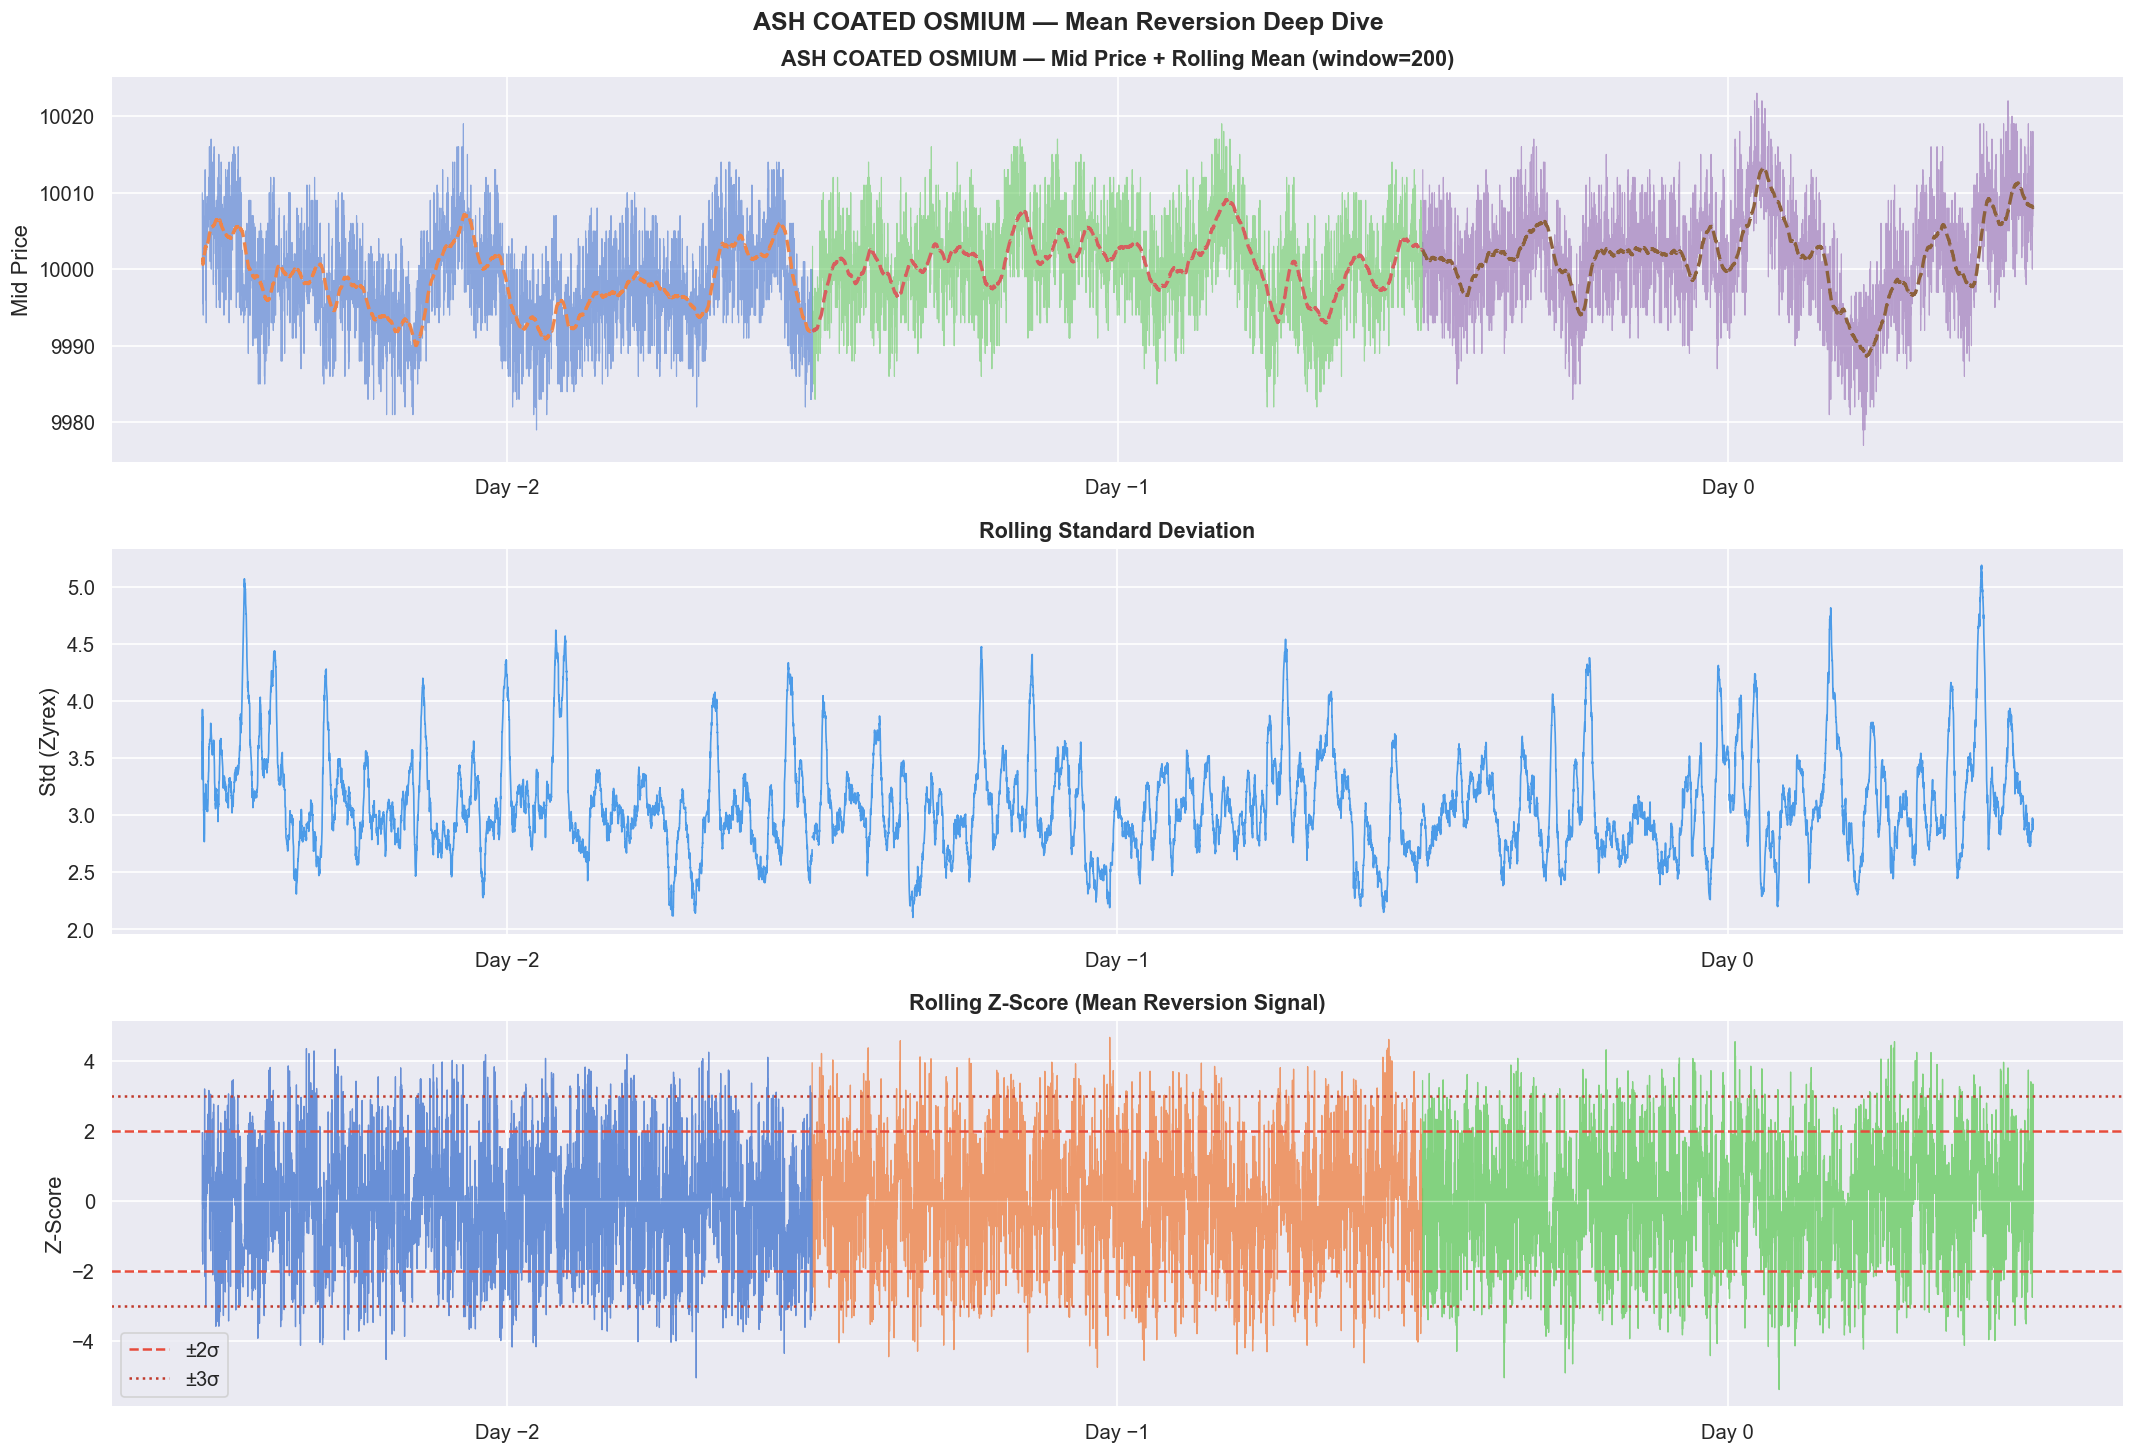

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=False)

# Plot per day
for day in [-2, -1, 0]:
    dsub = ash[ash['day'] == day]
    
    # Price + rolling mean
    axes[0].plot(dsub['global_ts'], dsub['mid_price'], linewidth=0.7, alpha=0.6)
    axes[0].plot(dsub['global_ts'], dsub['rolling_mean'], linewidth=2, linestyle='--')

axes[0].set_title(f'ASH COATED OSMIUM — Mid Price + Rolling Mean (window={WINDOW})', fontweight='bold')
axes[0].set_ylabel('Mid Price')
axes[0].set_xticks([0.5*OFFSET, 1.5*OFFSET, 2.5*OFFSET])
axes[0].set_xticklabels(['Day −2', 'Day −1', 'Day 0'])

# Rolling std
for day in [-2, -1, 0]:
    dsub = ash[ash['day'] == day]
    axes[1].plot(dsub['global_ts'], dsub['rolling_std'], linewidth=1.0, color=COLORS['ASH_COATED_OSMIUM'])

axes[1].set_title('Rolling Standard Deviation', fontweight='bold')
axes[1].set_ylabel('Std (Zyrex)')
axes[1].set_xticks([0.5*OFFSET, 1.5*OFFSET, 2.5*OFFSET])
axes[1].set_xticklabels(['Day −2', 'Day −1', 'Day 0'])

# Z-score
for day in [-2, -1, 0]:
    dsub = ash[ash['day'] == day]
    axes[2].plot(dsub['global_ts'], dsub['z_score'], linewidth=0.8, alpha=0.8)

axes[2].axhline( 2, color='#e74c3c', linestyle='--', linewidth=1.5, label='±2σ')
axes[2].axhline(-2, color='#e74c3c', linestyle='--', linewidth=1.5)
axes[2].axhline( 3, color='#c0392b', linestyle=':', linewidth=1.5, label='±3σ')
axes[2].axhline(-3, color='#c0392b', linestyle=':', linewidth=1.5)
axes[2].axhline( 0, color='white', linestyle='-', linewidth=0.8, alpha=0.4)
axes[2].set_title('Rolling Z-Score (Mean Reversion Signal)', fontweight='bold')
axes[2].set_ylabel('Z-Score')
axes[2].set_xticks([0.5*OFFSET, 1.5*OFFSET, 2.5*OFFSET])
axes[2].set_xticklabels(['Day −2', 'Day −1', 'Day 0'])
axes[2].legend()

plt.tight_layout()
plt.suptitle('ASH COATED OSMIUM — Mean Reversion Deep Dive', fontsize=15, fontweight='bold', y=1.01)
plt.show()


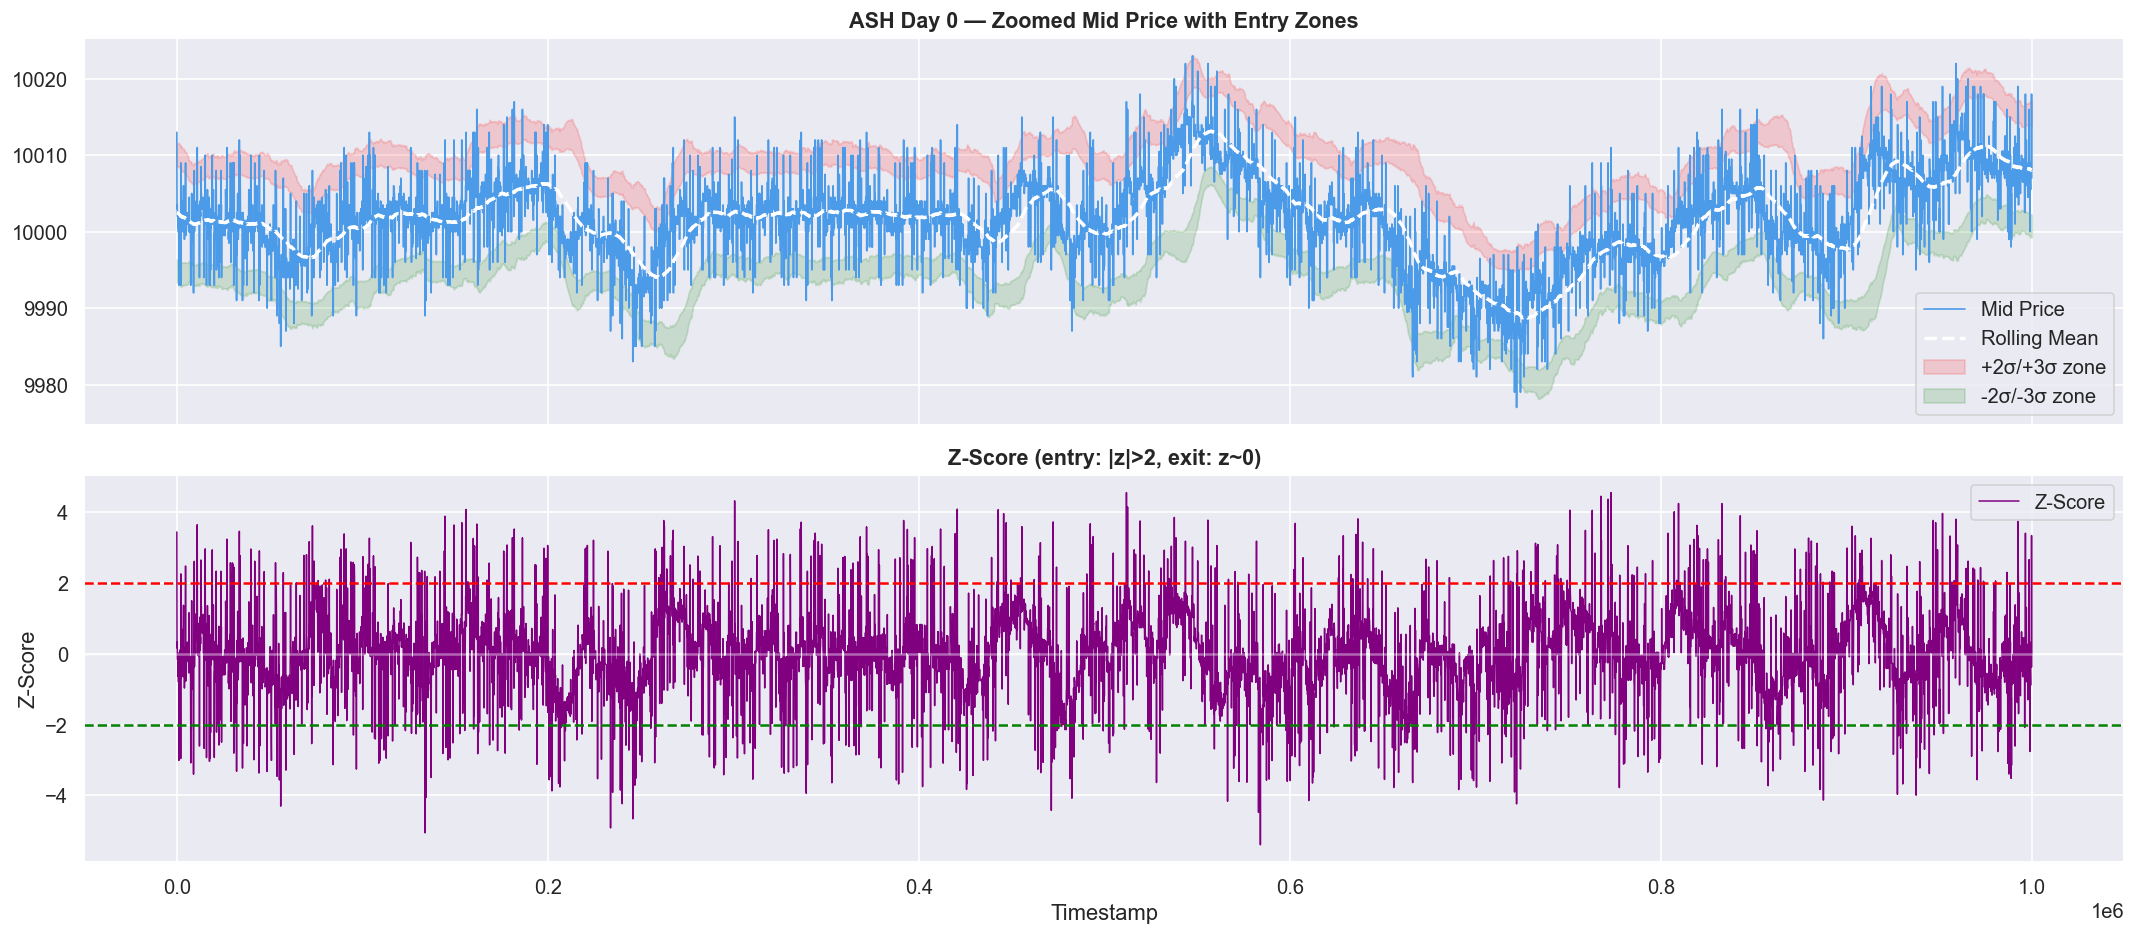

In [35]:
# ── Zoomed view — single day for detail ────────────────────────────────────
day_to_zoom = 0
zsub = ash[ash['day'] == day_to_zoom].copy()

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

axes[0].plot(zsub['timestamp'], zsub['mid_price'], color=COLORS['ASH_COATED_OSMIUM'],
             linewidth=1.0, label='Mid Price')
axes[0].plot(zsub['timestamp'], zsub['rolling_mean'], color='white',
             linewidth=2, linestyle='--', label='Rolling Mean')

# Shade entry zones
axes[0].fill_between(zsub['timestamp'],
                     zsub['rolling_mean'] + 2*zsub['rolling_std'],
                     zsub['rolling_mean'] + 3*zsub['rolling_std'],
                     alpha=0.15, color='red', label='+2σ/+3σ zone')
axes[0].fill_between(zsub['timestamp'],
                     zsub['rolling_mean'] - 2*zsub['rolling_std'],
                     zsub['rolling_mean'] - 3*zsub['rolling_std'],
                     alpha=0.15, color='green', label='-2σ/-3σ zone')
axes[0].set_title(f'ASH Day {day_to_zoom} — Zoomed Mid Price with Entry Zones', fontweight='bold')
axes[0].legend()

axes[1].plot(zsub['timestamp'], zsub['z_score'], linewidth=0.9, color='purple', label='Z-Score')
axes[1].axhline( 2, color='red',   linestyle='--', linewidth=1.5)
axes[1].axhline(-2, color='green', linestyle='--', linewidth=1.5)
axes[1].axhline( 0, color='white', linestyle='-', alpha=0.4)
axes[1].set_title('Z-Score (entry: |z|>2, exit: z~0)', fontweight='bold')
axes[1].set_ylabel('Z-Score')
axes[1].set_xlabel('Timestamp')
axes[1].legend()

plt.tight_layout()
plt.show()


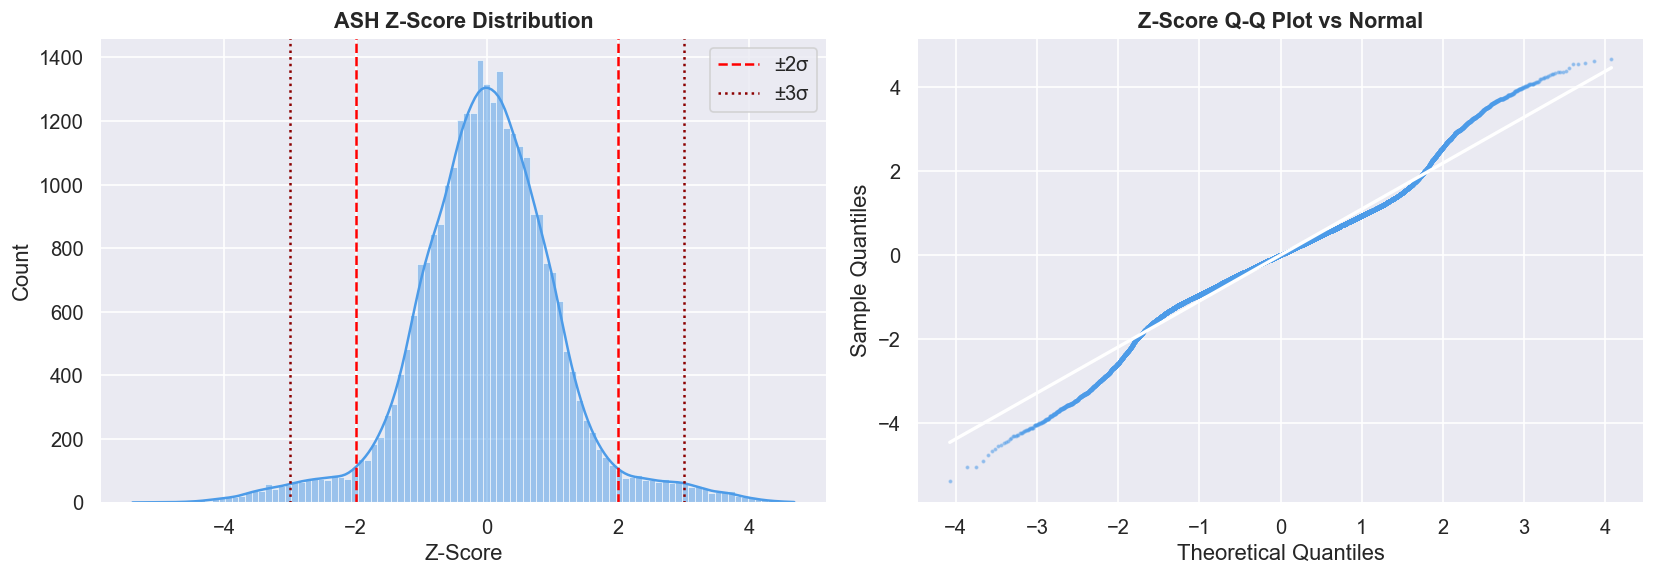

In [36]:
# ── Z-score distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(ash['z_score'].dropna(), bins=100, kde=True, ax=axes[0],
             color=COLORS['ASH_COATED_OSMIUM'])
axes[0].axvline(2,  color='red',   linestyle='--', label='±2σ')
axes[0].axvline(-2, color='red',   linestyle='--')
axes[0].axvline(3,  color='darkred', linestyle=':', label='±3σ')
axes[0].axvline(-3, color='darkred', linestyle=':')
axes[0].set_title('ASH Z-Score Distribution', fontweight='bold')
axes[0].set_xlabel('Z-Score')
axes[0].legend()

# QQ-plot vs normal
(osm, osr), (slope, intercept, r) = stats.probplot(ash['z_score'].dropna(), dist='norm')
axes[1].scatter(osm, osr, s=2, alpha=0.4, color=COLORS['ASH_COATED_OSMIUM'])
axes[1].plot(osm, slope*np.array(osm)+intercept, color='white', linewidth=2)
axes[1].set_title('Z-Score Q-Q Plot vs Normal', fontweight='bold')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()


## 6. Spread & Order Book Depth

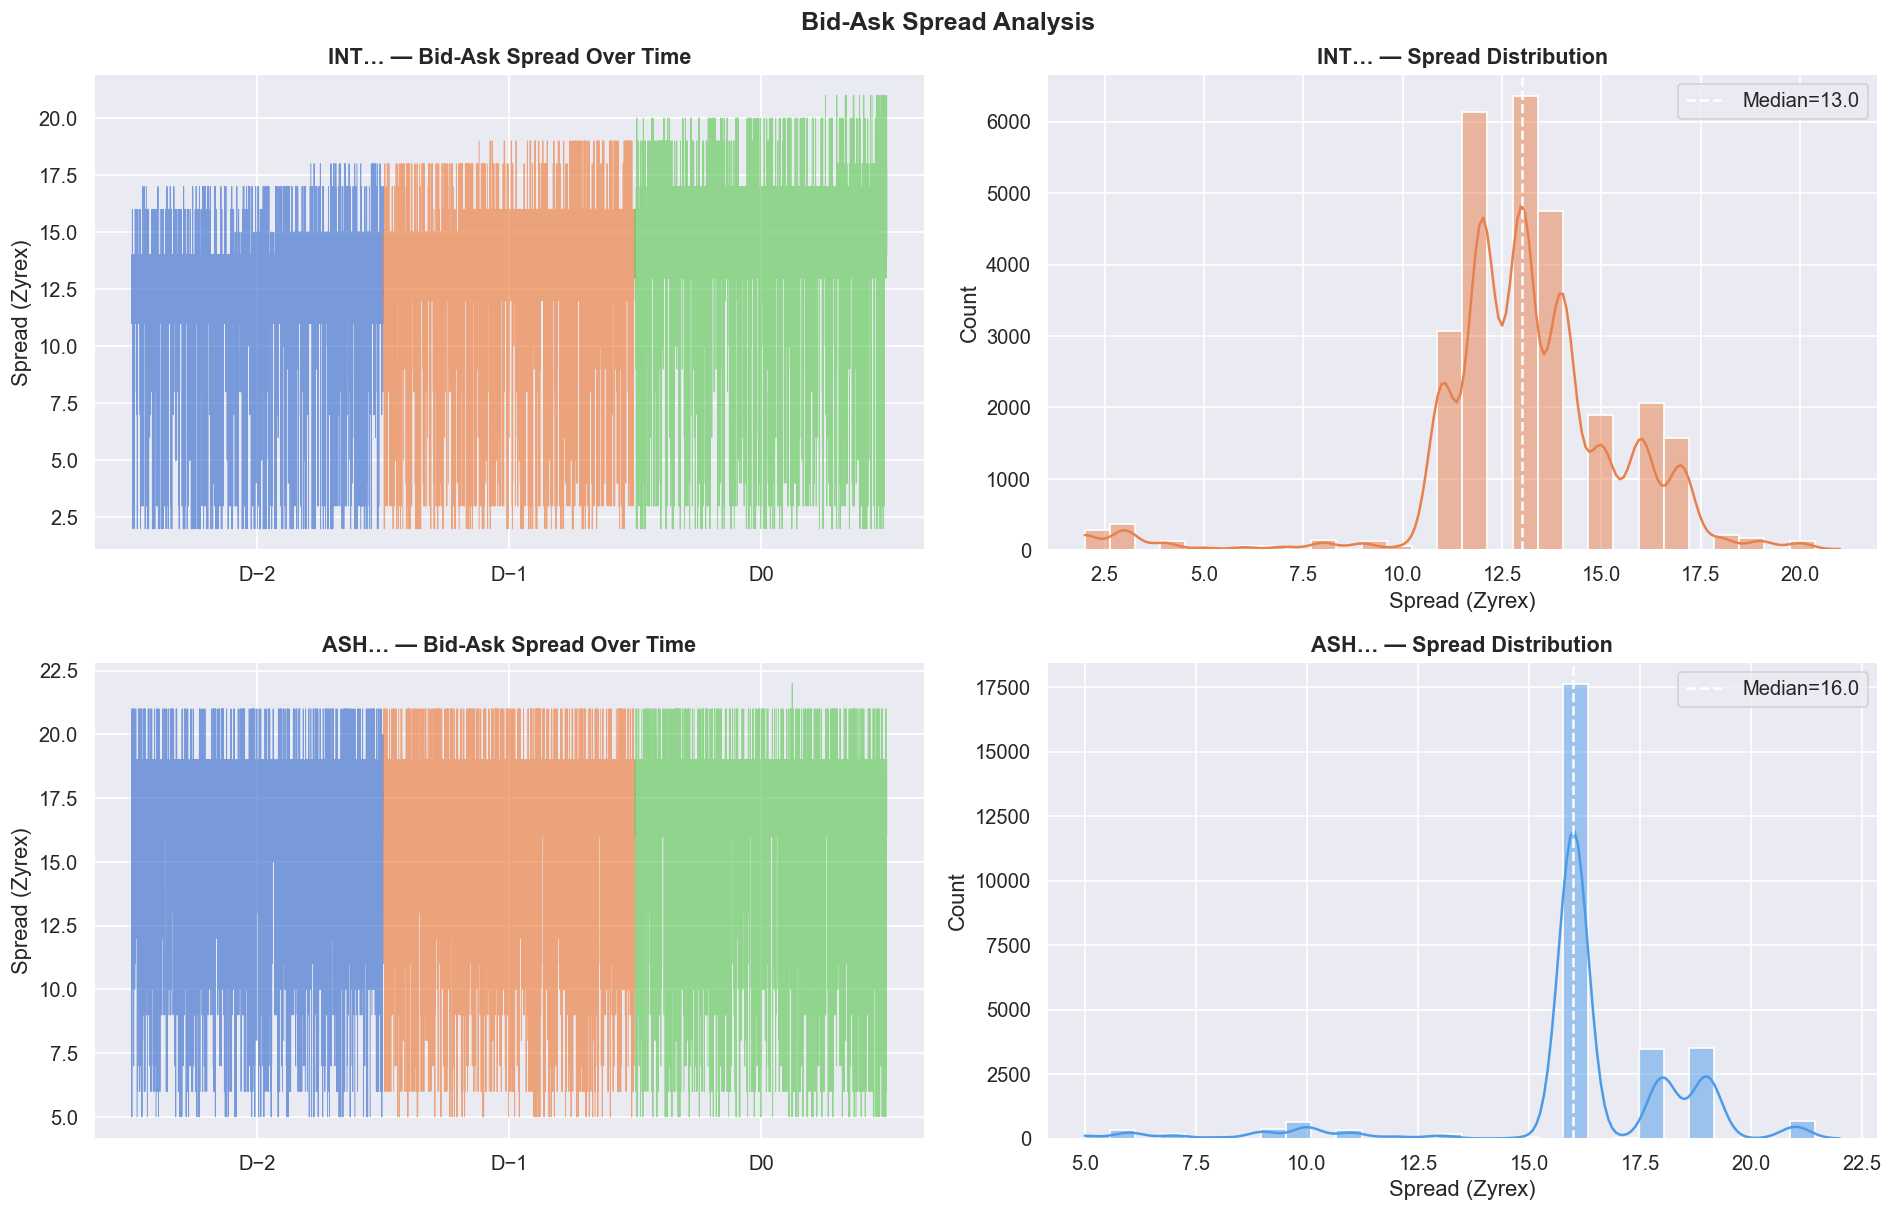

In [37]:
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, prod in enumerate(['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']):
    sub = prices[prices['product'] == prod].copy()
    color = COLORS[prod]

    # Spread over time
    ax = axes[row, 0]
    for day in [-2, -1, 0]:
        dsub = sub[sub['day'] == day]
        ax.plot(dsub['global_ts'], dsub['spread'], linewidth=0.6, alpha=0.7)
    ax.set_title(f'{prod[:3]}… — Bid-Ask Spread Over Time', fontweight='bold')
    ax.set_ylabel('Spread (Zyrex)')
    ax.set_xticks([0.5*OFFSET, 1.5*OFFSET, 2.5*OFFSET])
    ax.set_xticklabels(['D−2', 'D−1', 'D0'])

    # Spread distribution
    ax = axes[row, 1]
    sns.histplot(sub['spread'].dropna(), bins=30, kde=True, ax=ax, color=color)
    ax.axvline(sub['spread'].median(), color='white', linestyle='--',
               label=f'Median={sub["spread"].median():.1f}')
    ax.set_title(f'{prod[:3]}… — Spread Distribution', fontweight='bold')
    ax.set_xlabel('Spread (Zyrex)')
    ax.legend()

plt.tight_layout()
plt.suptitle('Bid-Ask Spread Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.show()


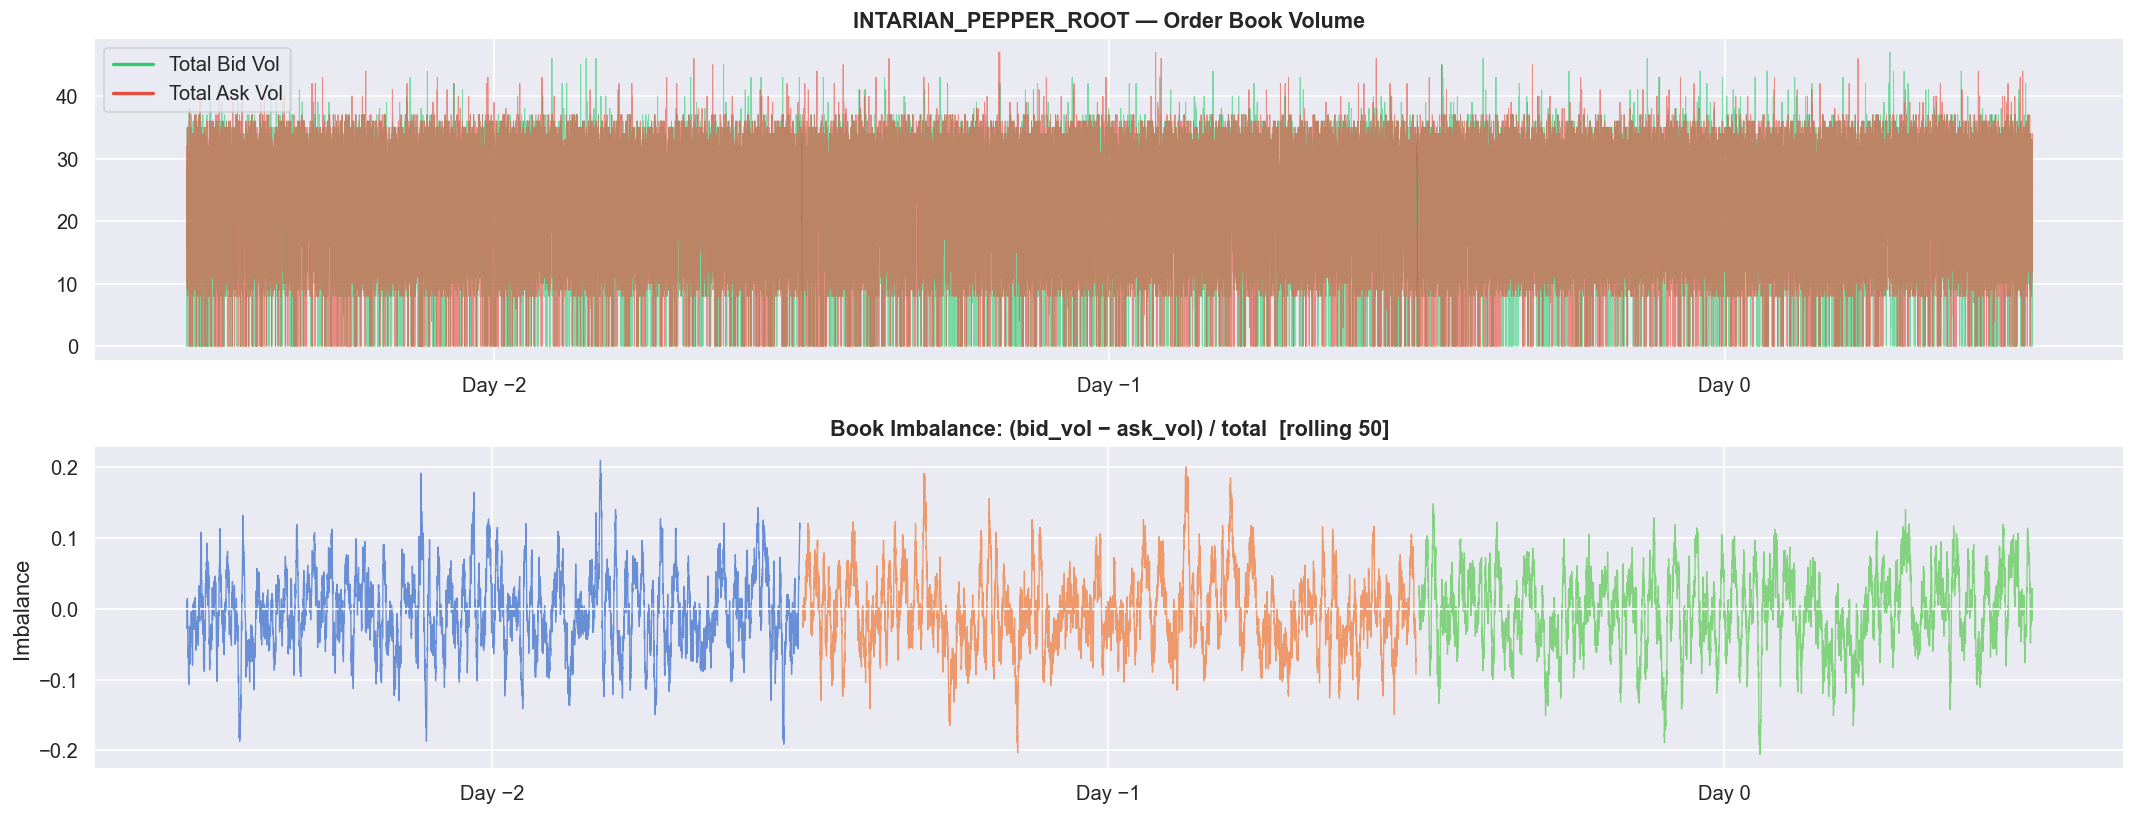

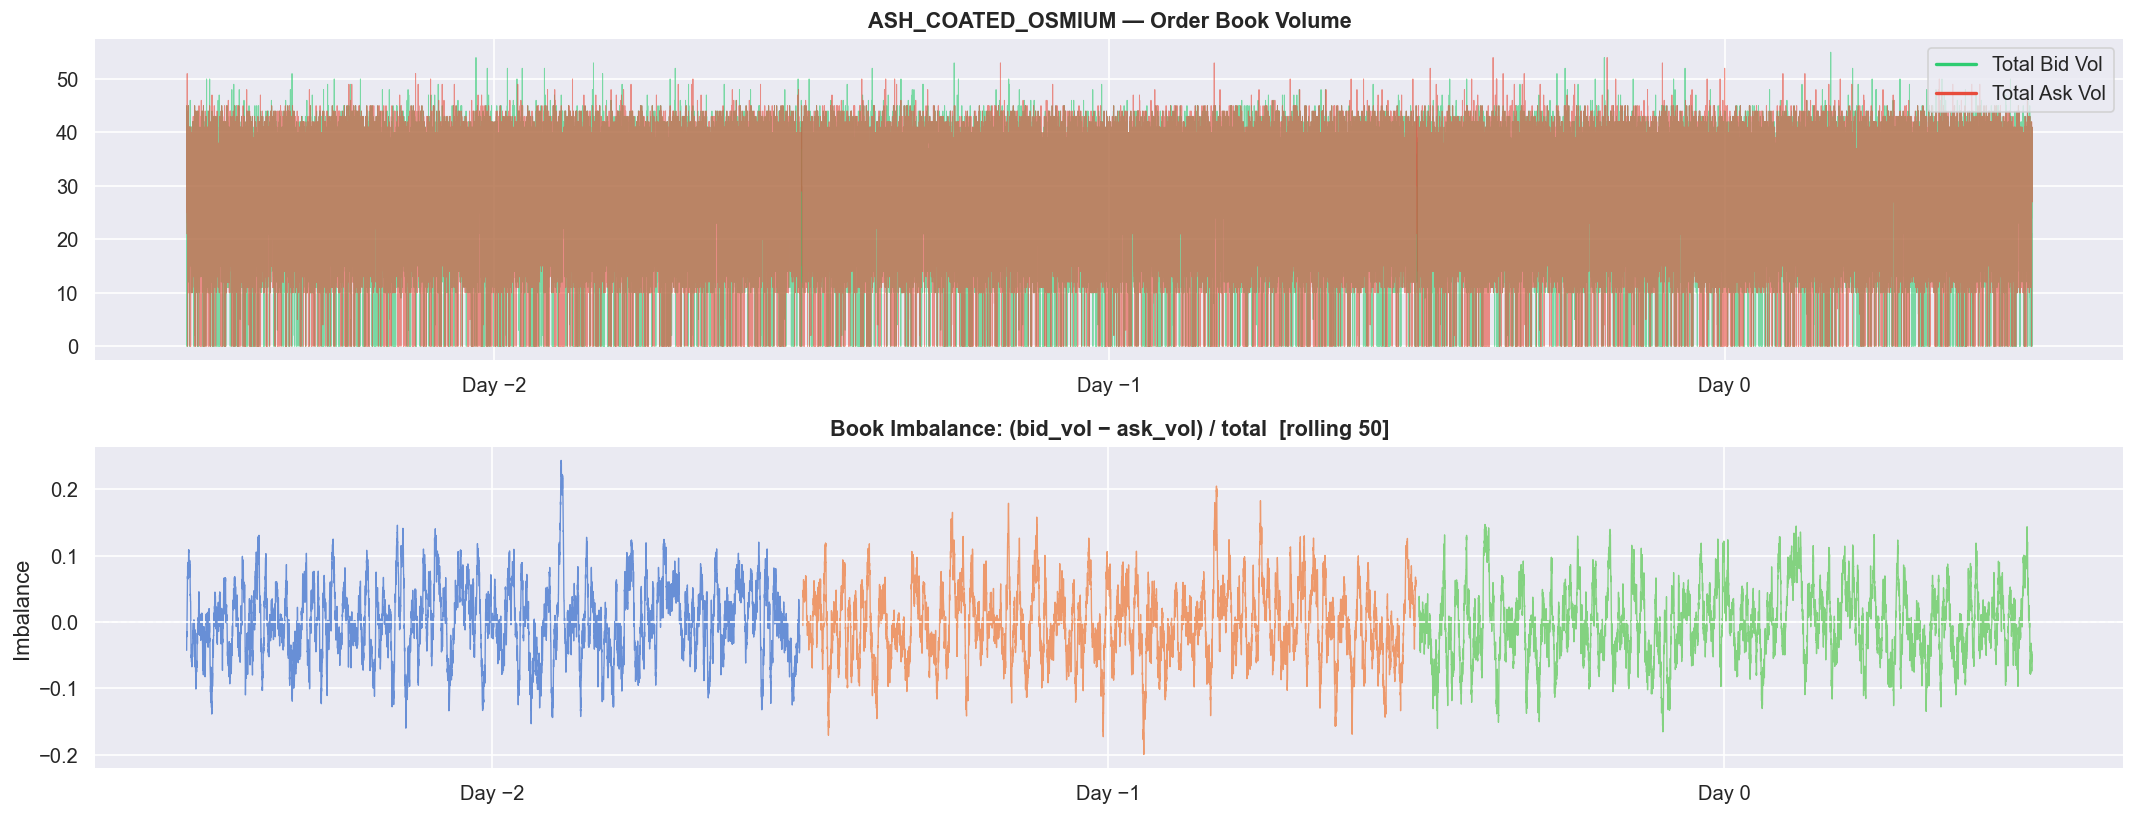

In [38]:
# ── Order book depth: total bid & ask volume ────────────────────────────────
for prod in ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']:
    sub = prices[prices['product'] == prod].copy()
    
    sub['total_bid_vol'] = (sub['bid_volume_1'].fillna(0) +
                            sub['bid_volume_2'].fillna(0) +
                            sub['bid_volume_3'].fillna(0))
    sub['total_ask_vol'] = (sub['ask_volume_1'].fillna(0) +
                            sub['ask_volume_2'].fillna(0) +
                            sub['ask_volume_3'].fillna(0))
    sub['book_imbalance'] = ((sub['total_bid_vol'] - sub['total_ask_vol']) /
                             (sub['total_bid_vol'] + sub['total_ask_vol']).replace(0, np.nan))
    
    fig, axes = plt.subplots(2, 1, figsize=(18, 7), sharex=False)
    
    for day in [-2, -1, 0]:
        dsub = sub[sub['day'] == day]
        axes[0].plot(dsub['global_ts'], dsub['total_bid_vol'], color=COLORS['bid'],
                     linewidth=0.6, alpha=0.6)
        axes[0].plot(dsub['global_ts'], dsub['total_ask_vol'], color=COLORS['ask'],
                     linewidth=0.6, alpha=0.6)
    
    from matplotlib.lines import Line2D
    axes[0].legend(handles=[
        Line2D([0],[0], color=COLORS['bid'], lw=2, label='Total Bid Vol'),
        Line2D([0],[0], color=COLORS['ask'], lw=2, label='Total Ask Vol'),
    ])
    axes[0].set_title(f'{prod} — Order Book Volume', fontweight='bold')
    axes[0].set_xticks([0.5*OFFSET, 1.5*OFFSET, 2.5*OFFSET])
    axes[0].set_xticklabels(['Day −2', 'Day −1', 'Day 0'])

    for day in [-2, -1, 0]:
        dsub = sub[sub['day'] == day]
        axes[1].plot(dsub['global_ts'], dsub['book_imbalance'].rolling(50).mean(),
                     linewidth=0.8, alpha=0.8)
    axes[1].axhline(0, color='white', linestyle='--', linewidth=1.0)
    axes[1].set_title('Book Imbalance: (bid_vol − ask_vol) / total  [rolling 50]', fontweight='bold')
    axes[1].set_ylabel('Imbalance')
    axes[1].set_xticks([0.5*OFFSET, 1.5*OFFSET, 2.5*OFFSET])
    axes[1].set_xticklabels(['Day −2', 'Day −1', 'Day 0'])
    
    plt.tight_layout()
    plt.show()


## 7. Trade Flow Analysis

C:\Users\hames\AppData\Local\Temp\ipykernel_18560\1159971255.py:25: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hames\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


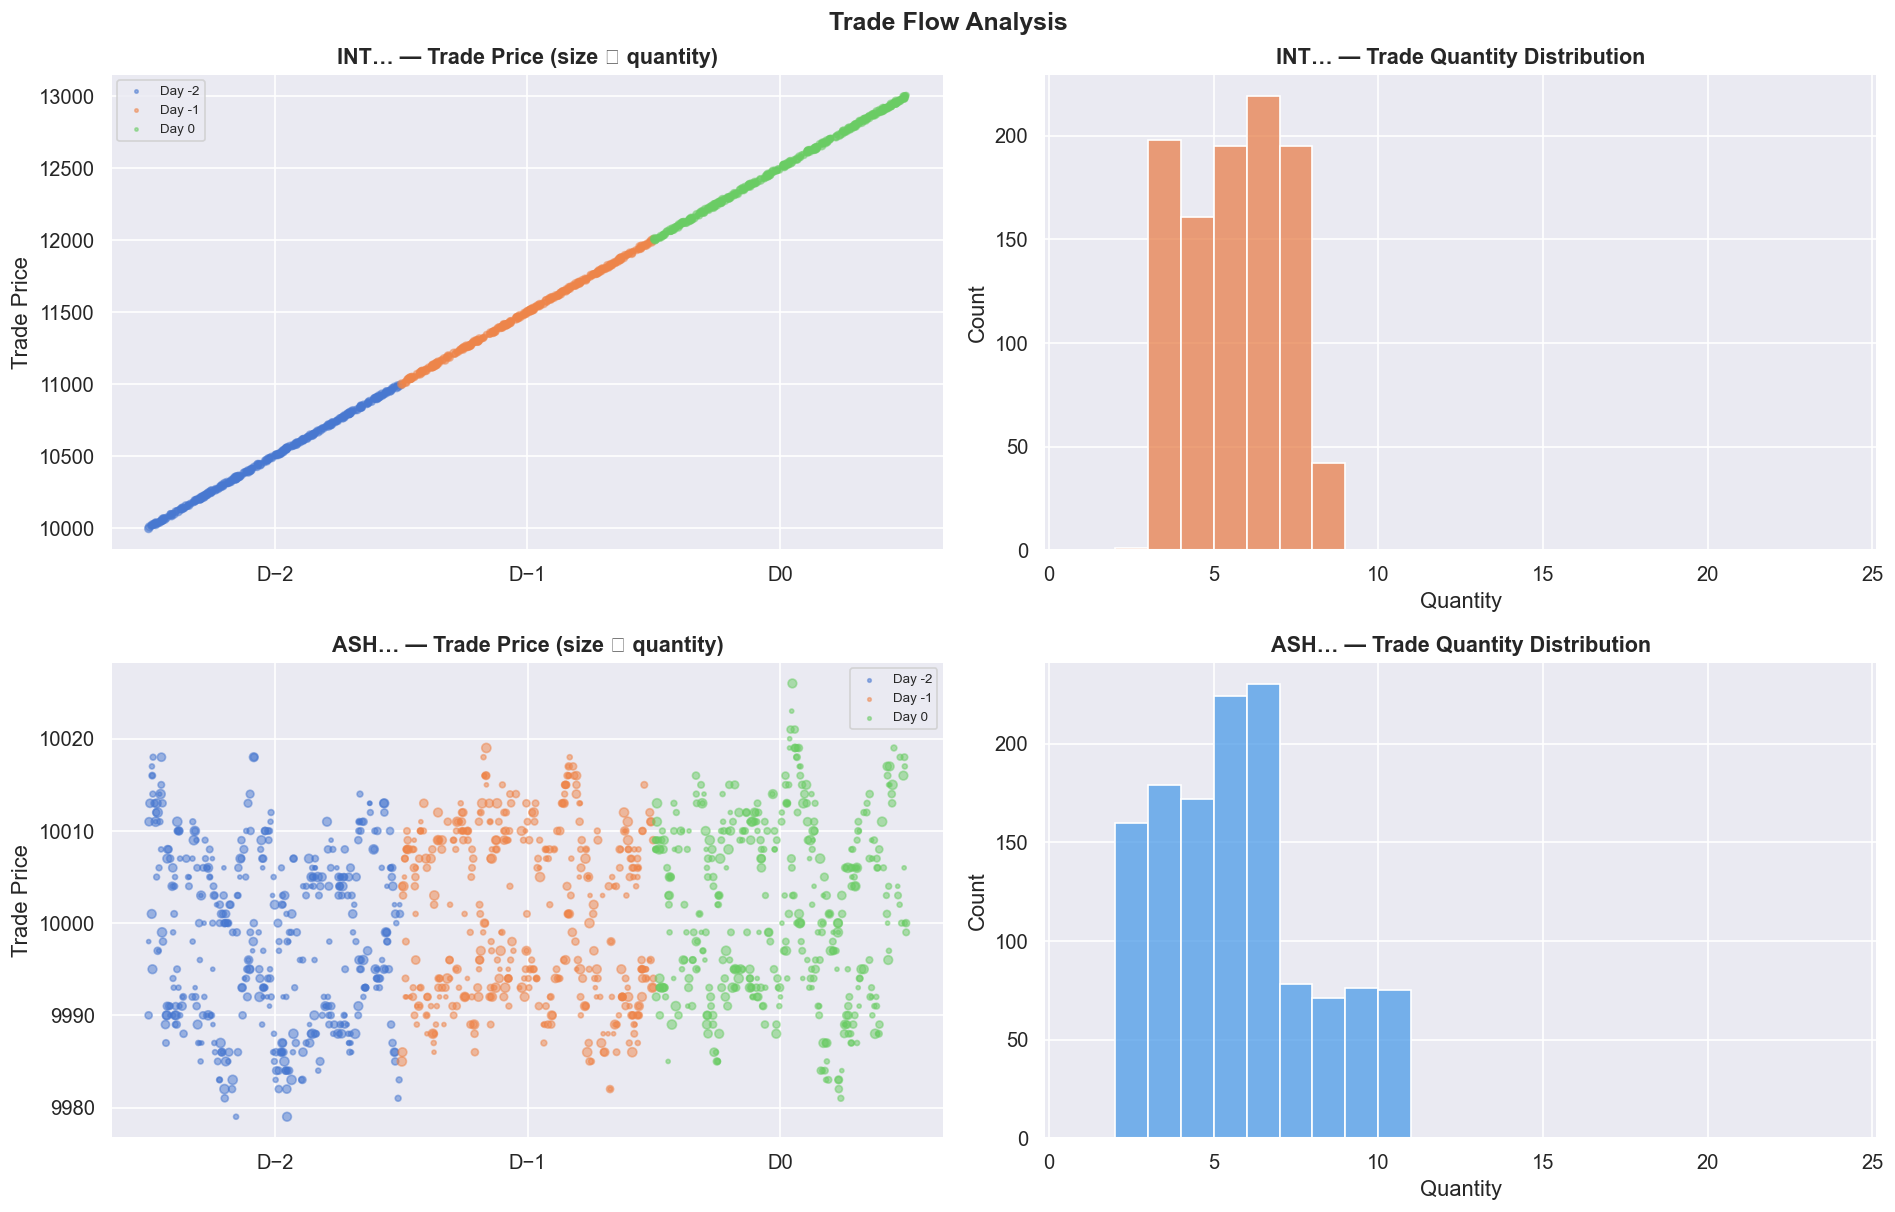

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, prod in enumerate(['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']):
    sub_t = trades[trades['symbol'] == prod].copy()
    color = COLORS[prod]

    # Trade price over time
    ax = axes[row, 0]
    for day in [-2, -1, 0]:
        dsub = sub_t[sub_t['day'] == day]
        ax.scatter(dsub['global_ts'], dsub['price'], s=dsub['quantity']*3,
                   alpha=0.5, label=f'Day {day}')
    ax.set_title(f'{prod[:3]}… — Trade Price (size ∝ quantity)', fontweight='bold')
    ax.set_ylabel('Trade Price')
    ax.set_xticks([0.5*OFFSET, 1.5*OFFSET, 2.5*OFFSET])
    ax.set_xticklabels(['D−2', 'D−1', 'D0'])
    ax.legend(fontsize=8, markerscale=0.5)

    # Quantity distribution
    ax = axes[row, 1]
    sns.histplot(sub_t['quantity'], bins=range(1, 25), kde=False, ax=ax, color=color)
    ax.set_title(f'{prod[:3]}… — Trade Quantity Distribution', fontweight='bold')
    ax.set_xlabel('Quantity')

plt.tight_layout()
plt.suptitle('Trade Flow Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.show()


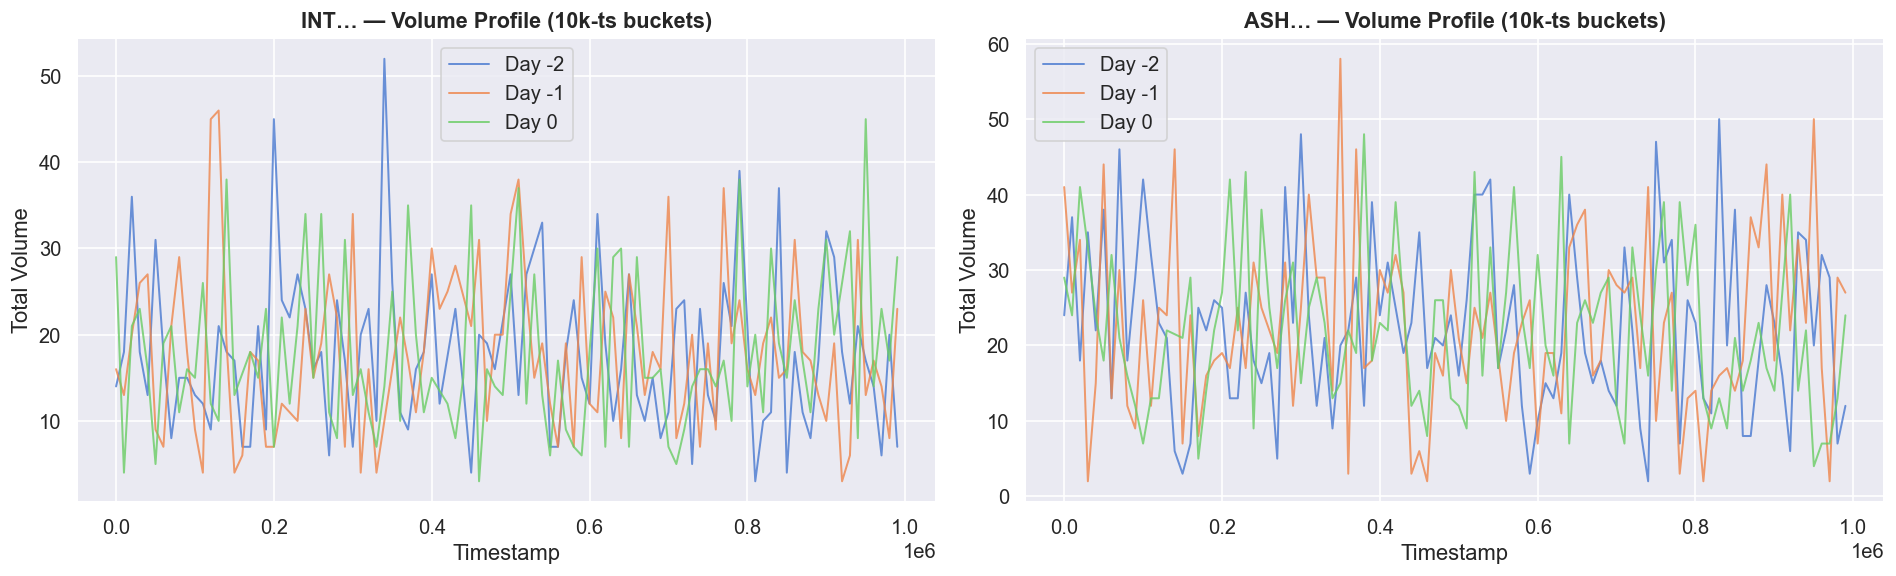

In [40]:
# ── Trades per timestamp bucket (volume profile) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, prod in zip(axes, ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']):
    sub_t = trades[trades['symbol'] == prod].copy()
    # Bucket by 10k timestamp
    sub_t['ts_bucket'] = (sub_t['timestamp'] // 10_000) * 10_000
    vol_profile = sub_t.groupby(['day', 'ts_bucket'])['quantity'].sum().reset_index()
    
    for day in [-2, -1, 0]:
        vp = vol_profile[vol_profile['day'] == day]
        ax.plot(vp['ts_bucket'], vp['quantity'], linewidth=1.2, alpha=0.8, label=f'Day {day}')
    
    ax.set_title(f'{prod[:3]}… — Volume Profile (10k-ts buckets)', fontweight='bold')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Total Volume')
    ax.legend()

plt.tight_layout()
plt.show()


C:\Users\hames\AppData\Local\Temp\ipykernel_18560\1337765015.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='large', y='price_impact', ax=axes[0],


ValueError: The palette dictionary is missing keys: {'False', 'True'}

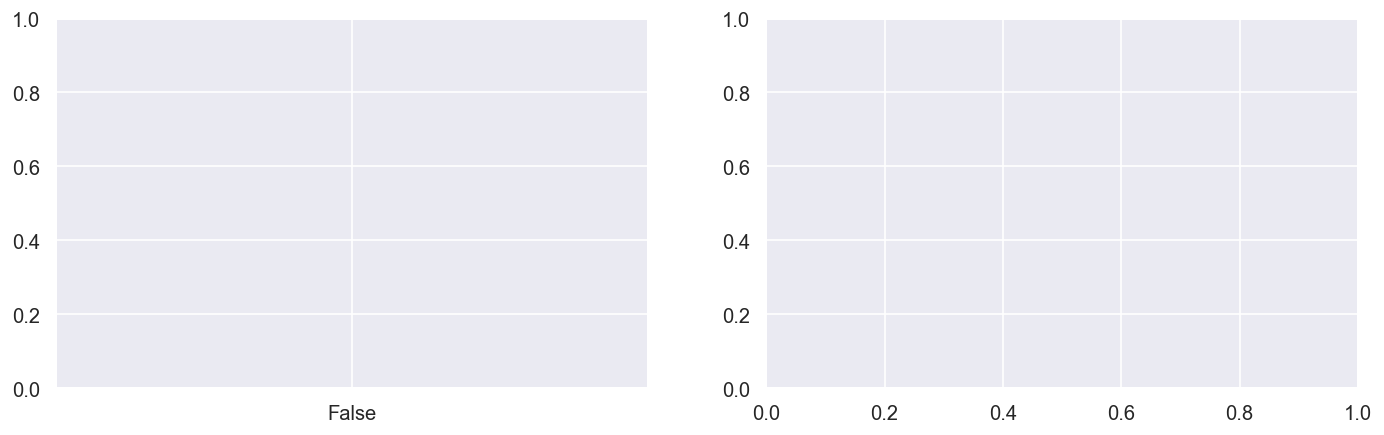

In [41]:
# ── Price impact of large vs small trades ────────────────────────────────────
for prod in ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']:
    sub_t  = trades[trades['symbol'] == prod].copy()
    sub_p  = prices[prices['product'] == prod].copy()
    
    # For each trade, find the mid-price just before and just after (next 5 rows)
    merged = pd.merge_asof(
        sub_t.sort_values('global_ts'),
        sub_p[['global_ts','mid_price']].sort_values('global_ts'),
        on='global_ts', direction='backward'
    ).rename(columns={'mid_price': 'mid_before'})
    
    # Next mid price (shift +1 in price series)
    sub_p_shifted = sub_p[['global_ts','mid_price']].copy()
    sub_p_shifted['global_ts'] -= 1  # shift back to match
    merged = pd.merge_asof(
        merged.sort_values('global_ts'),
        sub_p_shifted.rename(columns={'mid_price':'mid_after'}).sort_values('global_ts'),
        on='global_ts', direction='forward'
    )
    merged['price_impact'] = merged['mid_after'] - merged['mid_before']
    merged['large'] = merged['quantity'] >= merged['quantity'].quantile(0.75)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    sns.boxplot(data=merged, x='large', y='price_impact', ax=axes[0],
                palette={True: '#e74c3c', False: '#3498db'})
    axes[0].set_xticklabels(['Small (<Q75)', 'Large (≥Q75)'])
    axes[0].set_title(f'{prod[:3]}… — Price Impact: Large vs Small Trades', fontweight='bold')
    axes[0].set_ylabel('Δ Mid Price')
    
    sns.scatterplot(data=merged, x='quantity', y='price_impact', alpha=0.3,
                    color=COLORS[prod], ax=axes[1])
    axes[1].axhline(0, color='white', linestyle='--')
    axes[1].set_title(f'{prod[:3]}… — Quantity vs Price Impact', fontweight='bold')
    axes[1].set_xlabel('Trade Quantity')
    axes[1].set_ylabel('Δ Mid Price')
    
    plt.tight_layout()
    plt.show()


## 8. Autocorrelation & Return Analysis

In [ ]:
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, prod in enumerate(['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']):
    sub = prices[prices['product'] == prod].copy()
    
    # Returns
    sub['ret'] = sub['mid_price'].diff()
    sub['ret_pct'] = sub['mid_price'].pct_change()
    
    # Autocorrelation of returns
    ax = axes[row, 0]
    autocorrelation_plot(sub['ret'].dropna().values[:3000], ax=ax)
    ax.set_xlim(0, 50)
    ax.set_title(f'{prod[:3]}… — Return Autocorrelation (lags 1-50)', fontweight='bold')
    ax.set_xlabel('Lag')
    
    # Return distribution
    ax = axes[row, 1]
    ret_clean = sub['ret'].dropna()
    ret_clean = ret_clean[ret_clean.abs() < ret_clean.std() * 5]  # clip outliers
    sns.histplot(ret_clean, bins=60, kde=True, ax=ax, color=COLORS[prod])
    ax.axvline(0, color='white', linestyle='--')
    ax.set_title(f'{prod[:3]}… — Tick Return Distribution', fontweight='bold')
    ax.set_xlabel('Δ Mid Price')
    
    print(f"\n{prod}")
    print(f"  Lag-1 autocorr: {sub['ret'].autocorr(lag=1):.4f}")
    print(f"  Lag-2 autocorr: {sub['ret'].autocorr(lag=2):.4f}")
    print(f"  Return skew:    {ret_clean.skew():.4f}")
    print(f"  Return kurt:    {ret_clean.kurtosis():.4f}")

plt.tight_layout()
plt.show()


In [ ]:
# ── Forward return predictability ────────────────────────────────────────────
print("Forward return analysis — does z-score predict next move?\n")

ash = prices[prices['product'] == 'ASH_COATED_OSMIUM'].copy()
ash['rolling_mean'] = ash['mid_price'].rolling(200, min_periods=10).mean()
ash['rolling_std']  = ash['mid_price'].rolling(200, min_periods=10).std()
ash['z_score']      = (ash['mid_price'] - ash['rolling_mean']) / ash['rolling_std']

for fwd in [1, 5, 10, 20]:
    ash[f'fwd_ret_{fwd}'] = ash['mid_price'].shift(-fwd) - ash['mid_price']

# Bin by z-score quintile
ash['z_bin'] = pd.cut(ash['z_score'], bins=[-10,-2,-1,0,1,2,10],
                       labels=['<-2','-2:-1','-1:0','0:1','1:2','>2'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, fwd in zip(axes, [5, 20]):
    means = ash.groupby('z_bin', observed=True)[f'fwd_ret_{fwd}'].mean()
    means.plot(kind='bar', ax=ax, color=COLORS['ASH_COATED_OSMIUM'], edgecolor='white')
    ax.axhline(0, color='white', linestyle='--')
    ax.set_title(f'ASH — Mean Forward Return at t+{fwd} by Z-Score Bin', fontweight='bold')
    ax.set_xlabel('Z-Score Bin')
    ax.set_ylabel(f'Mean Return (t+{fwd})')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 9. Strategy Signals

### IPR Strategy: Trend-Following Market Make
- Estimate fair value via linear drift model
- Quote bid/ask symmetrically around `fair_value ± edge`
- Take aggressive when mid deviates from fair by `> threshold`

### ASH Strategy: Mean-Reversion Market Make
- Quote around rolling mean, widen when vol is high
- Aggressively take when `|z| > 2.0` (fade the move)
- Exit when z returns to 0


In [42]:
# ── IPR: Backtest trend-following take signal ────────────────────────────────
ipr = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT'].copy()

# Re-fit fair value
for day in [-2, -1, 0]:
    dsub = ipr[ipr['day'] == day]
    ts = dsub['timestamp'].values
    mp = dsub['mid_price'].values
    s, b, *_ = stats.linregress(ts, mp)
    ipr.loc[ipr['day'] == day, 'fair_value'] = s * ts + b

ipr['deviation'] = ipr['mid_price'] - ipr['fair_value']

TAKE_THRESH = 3.0  # Zyrex deviation to trigger a take

ipr['signal'] = 0
ipr.loc[ipr['deviation'] >  TAKE_THRESH, 'signal'] = -1  # price above fair → sell
ipr.loc[ipr['deviation'] < -TAKE_THRESH, 'signal'] =  1  # price below fair → buy

# Forward returns
FWD = 10
ipr['fwd_ret'] = ipr['mid_price'].shift(-FWD) - ipr['mid_price']

sig_trades = ipr[ipr['signal'] != 0].copy()
sig_trades['expected_pnl'] = sig_trades['signal'] * sig_trades['fwd_ret']

print("=== IPR Take-Signal Backtest ===")
print(f"Total signals: {len(sig_trades)}")
print(f"Buy signals:   {(sig_trades['signal']==1).sum()}")
print(f"Sell signals:  {(sig_trades['signal']==-1).sum()}")
print(f"Mean expected PnL per signal: {sig_trades['expected_pnl'].mean():.3f} Zyrex")
print(f"Win rate:      {(sig_trades['expected_pnl'] > 0).mean():.2%}")


=== IPR Take-Signal Backtest ===
Total signals: 3227
Buy signals:   1599
Sell signals:  1628
Mean expected PnL per signal: 6.089 Zyrex
Win rate:      96.78%


In [43]:
# ── ASH: Mean-reversion signal backtest ─────────────────────────────────────
ash = prices[prices['product'] == 'ASH_COATED_OSMIUM'].copy()
ash['rolling_mean'] = ash['mid_price'].rolling(200, min_periods=10).mean()
ash['rolling_std']  = ash['mid_price'].rolling(200, min_periods=10).std()
ash['z_score']      = (ash['mid_price'] - ash['rolling_mean']) / ash['rolling_std']

ENTRY_Z = 2.0
FWD = 20

ash['signal'] = 0
ash.loc[ash['z_score'] >  ENTRY_Z, 'signal'] = -1   # overbought → sell
ash.loc[ash['z_score'] < -ENTRY_Z, 'signal'] =  1   # oversold  → buy

ash['fwd_ret'] = ash['mid_price'].shift(-FWD) - ash['mid_price']

sig_trades = ash[ash['signal'] != 0].copy()
sig_trades['expected_pnl'] = sig_trades['signal'] * sig_trades['fwd_ret']

print("=== ASH Mean-Reversion Signal Backtest ===")
print(f"Entry threshold: |z| > {ENTRY_Z}")
print(f"Forward window:  {FWD} ticks")
print(f"Total signals:   {len(sig_trades)}")
print(f"Buy signals:     {(sig_trades['signal']==1).sum()}")
print(f"Sell signals:    {(sig_trades['signal']==-1).sum()}")
print(f"Mean expected PnL: {sig_trades['expected_pnl'].mean():.3f} Zyrex")
print(f"Win rate:          {(sig_trades['expected_pnl'] > 0).mean():.2%}")


=== ASH Mean-Reversion Signal Backtest ===
Entry threshold: |z| > 2.0
Forward window:  20 ticks
Total signals:   2278
Buy signals:     1140
Sell signals:    1138
Mean expected PnL: 7.491 Zyrex
Win rate:          95.70%


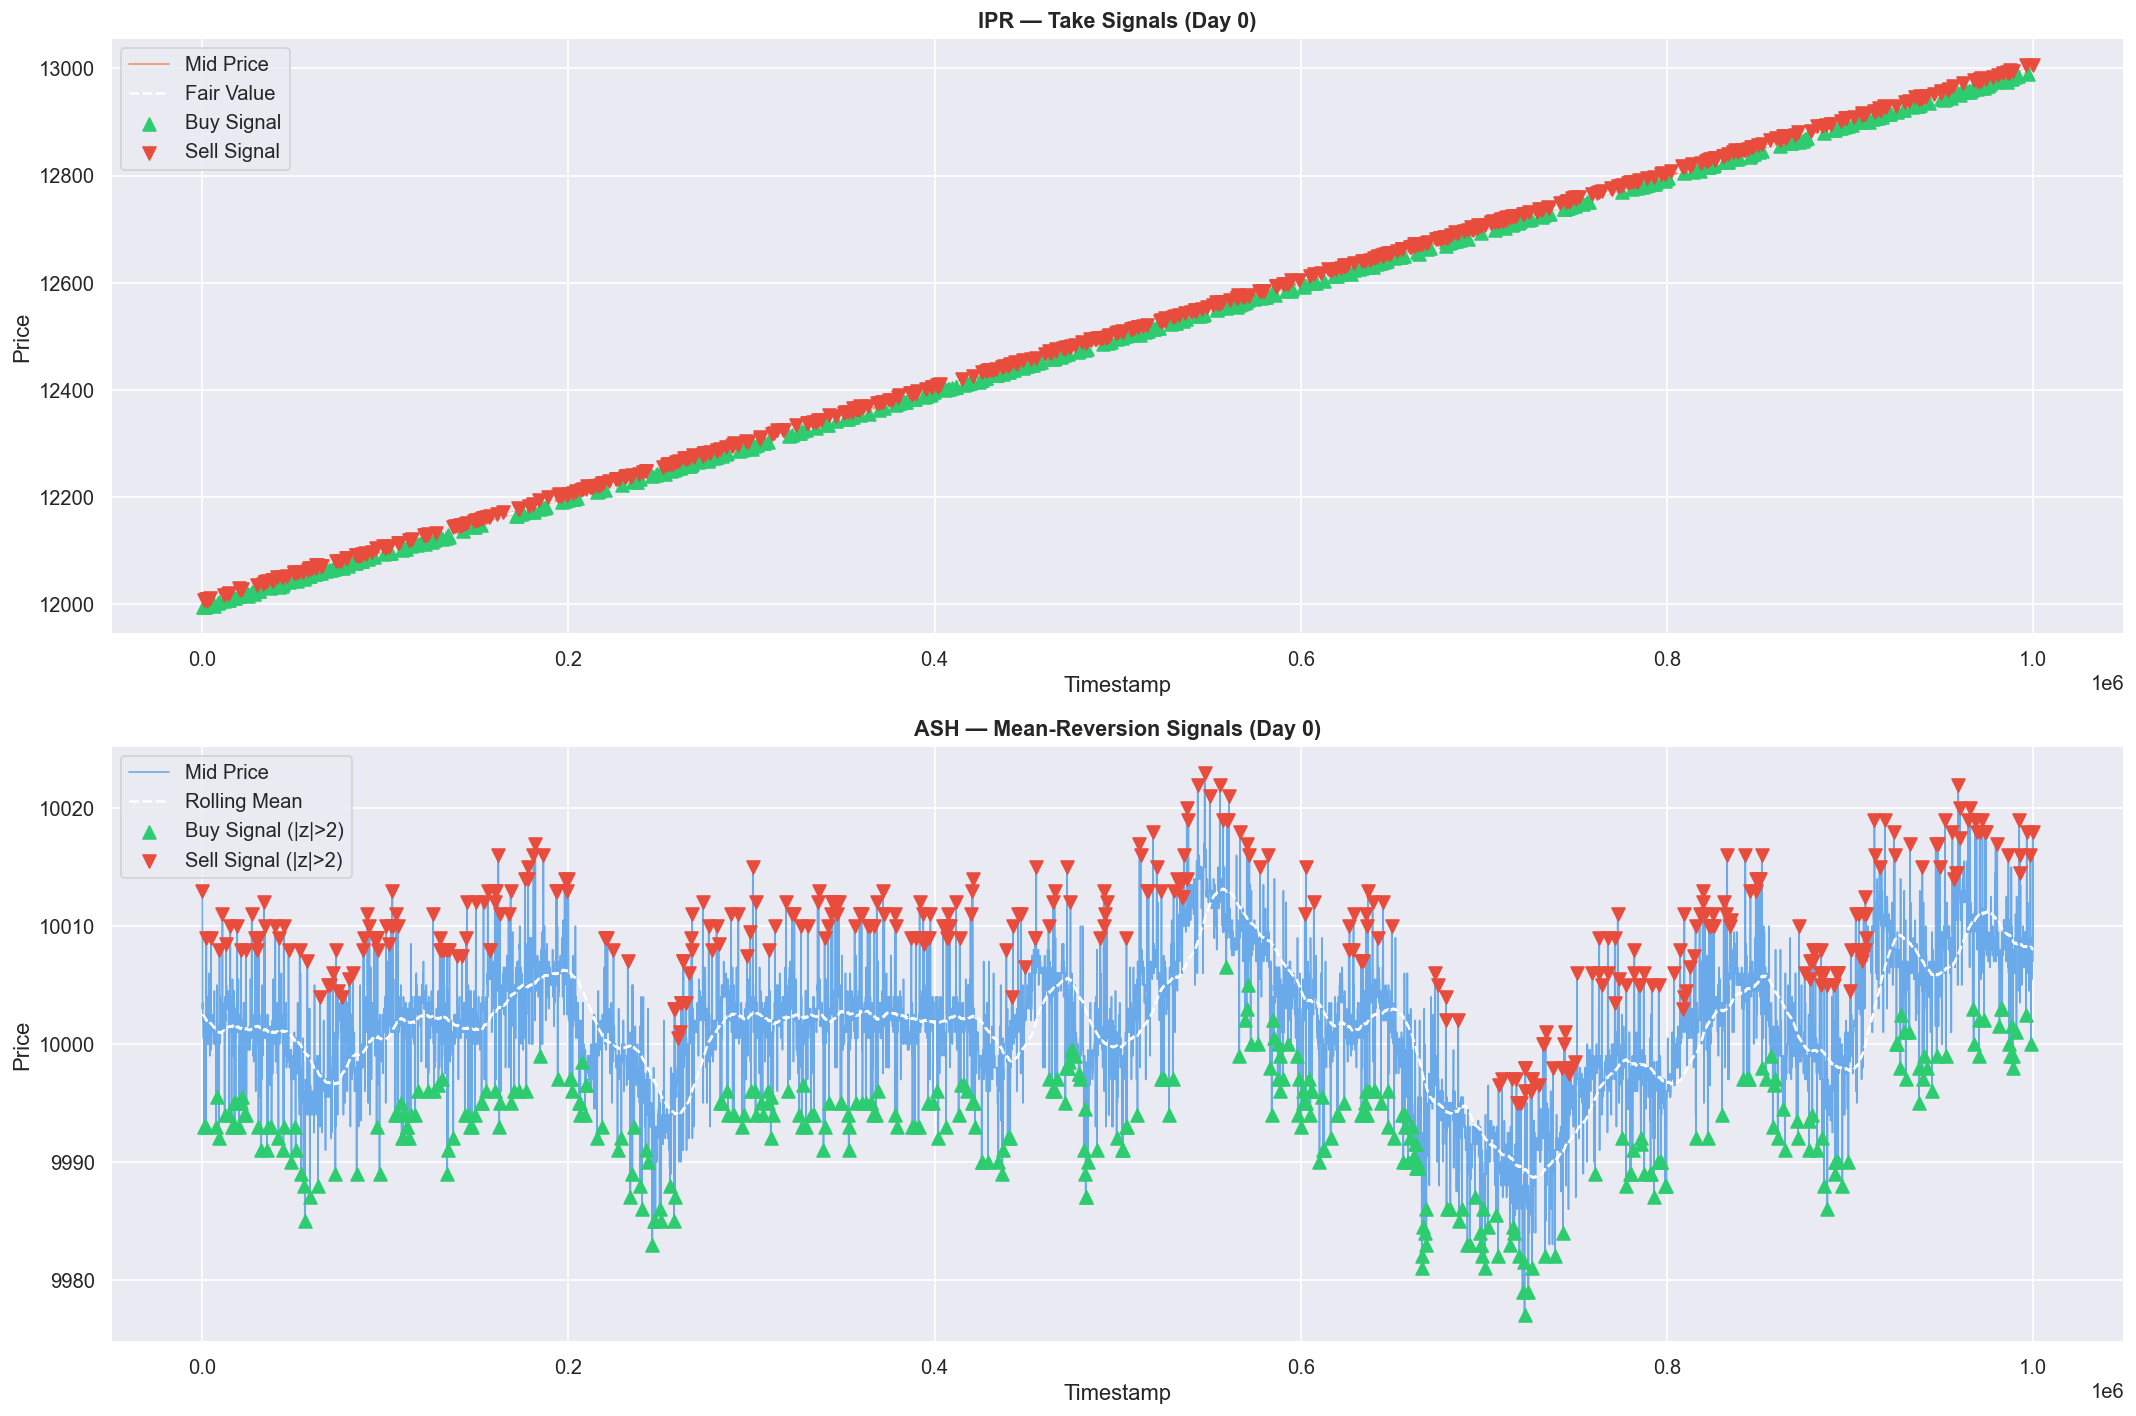

In [44]:
# ── Visualise signals on price chart ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=False)

# IPR signals
ipr_day = ipr[ipr['day'] == 0]
axes[0].plot(ipr_day['timestamp'], ipr_day['mid_price'], color=COLORS['INTARIAN_PEPPER_ROOT'],
             linewidth=1.0, alpha=0.8, label='Mid Price')
axes[0].plot(ipr_day['timestamp'], ipr_day['fair_value'], color='white',
             linewidth=1.5, linestyle='--', label='Fair Value')

buy_ipr  = ipr_day[ipr_day['signal'] ==  1]
sell_ipr = ipr_day[ipr_day['signal'] == -1]
axes[0].scatter(buy_ipr['timestamp'],  buy_ipr['mid_price'],  color='#2ecc71', marker='^', s=60, label='Buy Signal', zorder=5)
axes[0].scatter(sell_ipr['timestamp'], sell_ipr['mid_price'], color='#e74c3c', marker='v', s=60, label='Sell Signal', zorder=5)
axes[0].set_title('IPR — Take Signals (Day 0)', fontweight='bold')
axes[0].legend()
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Price')

# ASH signals
ash_day = ash[ash['day'] == 0]
axes[1].plot(ash_day['timestamp'], ash_day['mid_price'], color=COLORS['ASH_COATED_OSMIUM'],
             linewidth=1.0, alpha=0.8, label='Mid Price')
axes[1].plot(ash_day['timestamp'], ash_day['rolling_mean'], color='white',
             linewidth=1.5, linestyle='--', label='Rolling Mean')

buy_ash  = ash_day[ash_day['signal'] ==  1]
sell_ash = ash_day[ash_day['signal'] == -1]
axes[1].scatter(buy_ash['timestamp'],  buy_ash['mid_price'],  color='#2ecc71', marker='^', s=60, label='Buy Signal (|z|>2)',  zorder=5)
axes[1].scatter(sell_ash['timestamp'], sell_ash['mid_price'], color='#e74c3c', marker='v', s=60, label='Sell Signal (|z|>2)', zorder=5)
axes[1].set_title('ASH — Mean-Reversion Signals (Day 0)', fontweight='bold')
axes[1].legend()
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()


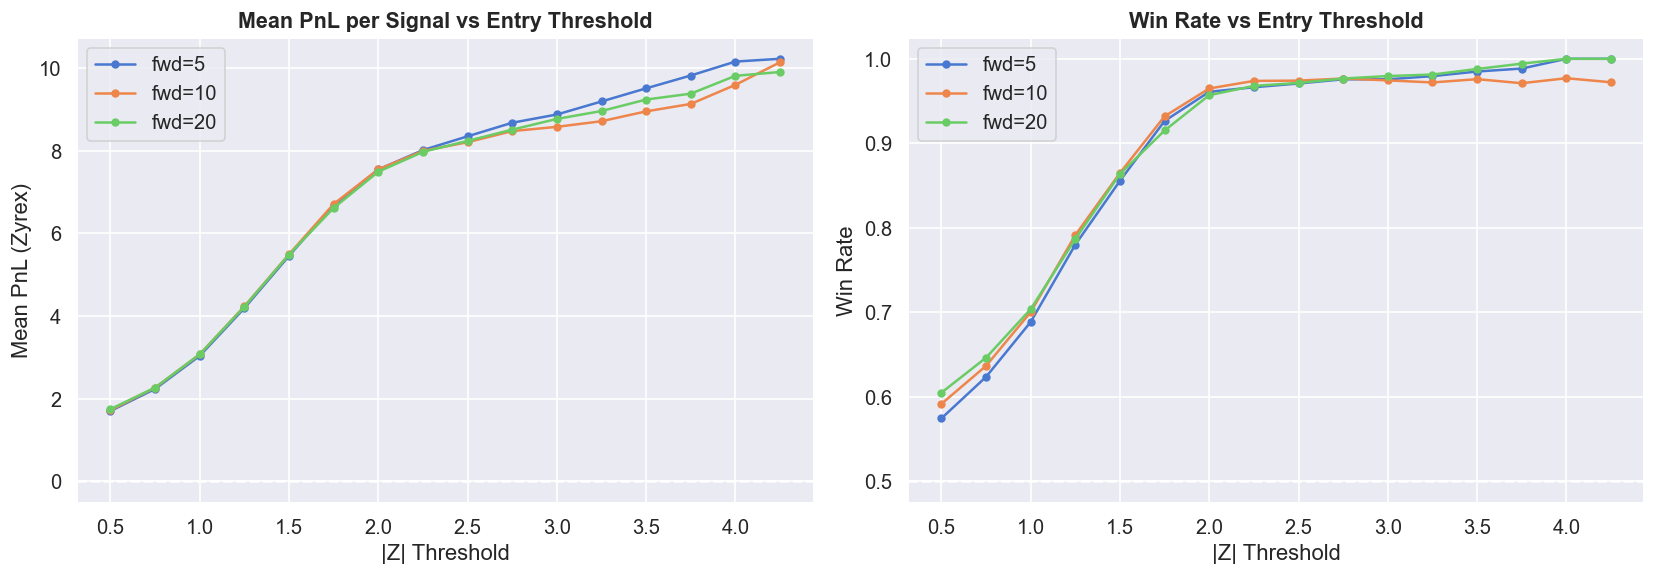

Best config by mean PnL:
 threshold  fwd  n_signals  mean_pnl  win_rate
      4.25    5         36 10.222222  1.000000
      4.00    5         87 10.155172  1.000000
      4.25   10         36 10.138889  0.972222
      4.25   20         36  9.902778  1.000000
      3.75    5        173  9.817919  0.988439


In [45]:
# ── ASH: Optimal entry threshold sweep ───────────────────────────────────────
thresholds = np.arange(0.5, 4.5, 0.25)
results = []

for thresh in thresholds:
    for fwd in [5, 10, 20]:
        sigs = ash[ash['z_score'].abs() > thresh].copy()
        sigs['signal'] = np.where(sigs['z_score'] < -thresh, 1, -1)
        sigs['fwd_ret'] = ash['mid_price'].shift(-fwd).reindex(sigs.index) - sigs['mid_price']
        sigs['pnl'] = sigs['signal'] * sigs['fwd_ret']
        results.append({
            'threshold': thresh,
            'fwd': fwd,
            'n_signals': len(sigs),
            'mean_pnl': sigs['pnl'].mean(),
            'win_rate': (sigs['pnl'] > 0).mean(),
        })

res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fwd in [5, 10, 20]:
    sub = res_df[res_df['fwd'] == fwd]
    axes[0].plot(sub['threshold'], sub['mean_pnl'], marker='o', markersize=4, label=f'fwd={fwd}')
    axes[1].plot(sub['threshold'], sub['win_rate'],  marker='o', markersize=4, label=f'fwd={fwd}')

axes[0].axhline(0, color='white', linestyle='--')
axes[0].set_title('Mean PnL per Signal vs Entry Threshold', fontweight='bold')
axes[0].set_xlabel('|Z| Threshold')
axes[0].set_ylabel('Mean PnL (Zyrex)')
axes[0].legend()

axes[1].axhline(0.5, color='white', linestyle='--')
axes[1].set_title('Win Rate vs Entry Threshold', fontweight='bold')
axes[1].set_xlabel('|Z| Threshold')
axes[1].set_ylabel('Win Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Best config by mean PnL:")
print(res_df.sort_values('mean_pnl', ascending=False).head(5).to_string(index=False))


## 10. Key Takeaways

### INTARIAN PEPPER ROOT (IPR)
| Observation | Implication |
|---|---|
| Drifts **+1,000 Zyrex/day** linearly | Simple linear model captures fair value |
| Residuals are near-zero, mean-reverting | Tight quotes around fair value → high edge |
| Spread ~13 Zyrex consistently | Quote inside spread with positive edge |
| **Strategy:** Market make around linear fair value; aggressively take when price deviates > 3 Zyrex | |

### ASH COATED OSMIUM (ACO)
| Observation | Implication |
|---|---|
| Stable mean ~10,000 across all days | True fair value ≈ 10,000 |
| Rolling std ≈ 4–6 Zyrex | Tight vol regime; small spreads on quotes |
| Neg. lag-1 autocorrelation | Mean-reversion is real; z>2 is tradeable |
| Spread ~16 Zyrex | Quote aggressively to capture spread |
| **Strategy:** Mean reversion — fade z>2, target z=0 exit; market make around 10,000 with ±3 Zyrex edge | |

### General
- Both products **benefit from market making** — the primary alpha source is the spread
- IPR is a **trend** product (within-day linear drift); ACO is a **mean-reversion** product
- Large trades cause minimal lasting price impact — reversion is fast
- Position limits will be the binding constraint; focus on **edge quality** over volume
